# Federated learning under a communication budget

### Quantization, partial participation and robust aggregation on non-IID data (UCI HAR)

*Course project: module "IA avancée", subject EMB-5 (federated learning under a communication constraint).*
**Author:** _add your name here_

---

**Contents**

1. Introduction
2. Step 1: Setup, data and heterogeneity
3. Step 2: Model, local training and baselines
4. Step 3: Plain FedAvg
5. Step 4: Partial participation
6. Step 5: Compression (quantization)
7. Step 6: Corrupted clients against plain FedAvg
8. Step 7: Robust aggregation
9. Step 8: Combined experiments
10. Step 9: How much to trim
11. Step 10: Robustness of the findings to model and training choices
12. Step 11: Seed-level failures
13. Step 12: Other attacks and strengths
14. Conclusions, limitations and future work

## 1. Introduction

### The problem
In federated learning, many clients (phones, hospitals, sensors) each hold their own data and train a shared model without sending the raw data anywhere. In each round a server sends the current model to some clients, every client trains it on its local data and returns an **update**, and the server **aggregates** the updates into a new global model.

Three practical difficulties make this hard:

- **Communication cost.** Every update has the size of the model, and bandwidth is limited.
- **Heterogeneous (non-IID) data.** Clients see different data, so their updates pull the model in different directions.
- **Unreliable or corrupted clients.** Some clients are offline, faulty or malicious and send useless or harmful updates.

### Research question
> For a **fixed communication budget**, which combination of **update quantization**, **partial participation** and **robust aggregation** best preserves convergence on **non-IID** data, including when some clients are corrupted?

### Approach
Everything is simulated in a single Python process: one server and 21 clients, all using the same small neural network. The three levers are compared **at the same number of uploaded bytes**, not at the same number of rounds:

| Lever | Values tested |
|---|---|
| Compression of each update | 32-bit (none), 8-bit and 4-bit uniform quantization |
| Participation | 20% or 100% of the clients speak in each round (50% in Step 4) |
| Aggregation | FedAvg, coordinate-wise median, trimmed mean |

Two kinds of data heterogeneity are used:

- **Natural split:** one client per real person. The activities are balanced for every person, but sensor values differ from person to person (feature shift).
- **Dirichlet split:** all training windows are redistributed over 21 clients with a label skew controlled by a parameter `alpha` (small alpha means each client sees only a few activities).

Corrupted clients ("liars" in the tables and plots) are added from Step 6 on: 2 of the 21 clients (10%) send a manipulated update.

### Dataset and use case
**UCI Human Activity Recognition Using Smartphones (HAR).** Each sample is a window of smartphone motion-sensor signals described by 561 pre-computed features, labelled with one of 6 activities (walking, upstairs, downstairs, sitting, standing, laying). The official split is used: 7,352 training windows from 21 subjects and 2,947 test windows from 9 other subjects.

*Use case:* a shared activity-recognition model trained across phones. Raw sensor data stays on the phone (privacy), mobile data is limited (the byte budget), phones are not always online (partial participation) and some devices are faulty or malicious (corrupted clients). The 9 test subjects never take part in training, so the test accuracy answers the question "does the model work for a new user?".

### Model
A multilayer perceptron 561 → 128 → 64 → 6 with 80,582 parameters. One full 32-bit update is 322 KB, so one round with all 21 clients costs about 6.8 MB of uploads. Only uploads are counted in the byte budget.

### Baselines
| Baseline | Role |
|---|---|
| Centralized training on all pooled data | Upper bound that ignores privacy and communication |
| Local-only training (one client alone) | Lower bound: what a client gets without federation |
| Plain FedAvg, honest clients, all clients, 32-bit | The federated reference every other configuration is compared with |
| Plain FedAvg with corrupted clients | Measures the damage of the attack when there is no defense |

### Metrics
| Question | Metric |
|---|---|
| How good is the model? | Accuracy on the 9 unseen test subjects (macro-F1 and a confusion matrix as diagnostics) |
| Who is left behind? | Worst accuracy among the unseen subjects, and worst accuracy reached late in a run |
| How cheap is it? | Accuracy against uploaded bytes, accuracy at fixed budgets, and MB needed to reach a target accuracy |
| What does an attack cost? | Accuracy without corrupted clients minus accuracy with 10% corrupted clients |
| What does robustness cost? | Accuracy of a robust rule minus FedAvg, with no attack |
| How noisy is the result? | Mean and standard deviation over seeds |

The project statement also asks for performance against bytes exchanged, worst-client performance and robustness to 10% corrupted clients: all three are covered.

### Conventions used throughout
- **Seeds:** 3 seeds (0, 1, 2) unless stated. A seed changes the initialization, the Dirichlet split, which clients speak in each round and which clients are corrupted. The natural split is the same for every seed. Tables show mean ± standard deviation over seeds.
- **Byte counting:** a 32-bit update costs 4 bytes per parameter; a `b`-bit quantized update costs `b/8` bytes per parameter plus 4 bytes for its scale. Uploads only.
- **Quantization:** the largest entry of the update sets the scale, values are rounded to integers in `[-(2^(b-1)-1), 2^(b-1)-1]`. 8-bit uses nearest rounding. 4-bit uses stochastic rounding from Step 8 on (Step 5 compares both).
- **Corrupted clients:** a fixed set of 2 of the 21 clients per seed. The main attack is a **sign flip** with strength `s` (written `x3`, `x10`...): the client sends `-s` times its honest update. Other attacks are defined in Step 12.
- **Trimmed mean:** drops the `ceil(0.1 k)` smallest and largest values of every coordinate (3 of 21 clients, 1 of 4), then averages the rest. It is told the share of corrupted clients, which a real server would not know. With 4 clients per round it is the same rule as the median.
- **"Second half" summaries (Step 8 on):** each run is summarized by the mean and the minimum accuracy over the second half of its rounds, because a single bad round near the end distorts last-round numbers at low participation.
- **Terms:** `natural` is the one-client-per-person split; `alpha = 0.1` is the Dirichlet split with strong label skew; `q8` and `q4` are 8-bit and 4-bit messages.

### Roadmap
| Step | Question |
|---|---|
| 1 | What does the data look like, and how is heterogeneity controlled? |
| 2 | What do the model, the ceiling (centralized) and the floor (local-only) look like? |
| 3 | How close does plain FedAvg get, and how fast? |
| 4 | What does partial participation save at equal bytes? |
| 5 | What does quantization save at equal bytes, and does it cost accuracy? |
| 6 | How much damage do corrupted clients do to plain FedAvg? |
| 7 | How much does robust aggregation repair, and what does it cost? |
| 8 | Which combination is best in each scenario under the same byte budget? |
| 9 | How many values should the trimmed mean drop? |
| 10 | Do the findings survive a different model size, learning rate and number of local epochs? |
| 11 | How often does a single seed fail, and why? |
| 12 | Do the findings hold for other attack strengths and types? |

### How to run
- **Requirements:** Python 3 with `torch`, `numpy`, `pandas`, `matplotlib`, `scikit-learn` (see `requirements.txt`). A GPU is not needed. This notebook was produced with Python 3.13.1 and PyTorch 2.14.1 (CPU).
- **Data:** the first cells download the HAR dataset into the working directory (internet connection needed; three mirrors are tried).
- **Run time:** on a CPU, the grids of Steps 8, 9, 10 and 12 took roughly 50, 20, 90 and 45 minutes. Steps 4 to 7 were not timed separately. Their runs are not cached, so a full run from scratch takes several hours.
- **Caching:** Steps 8, 9, 10 and 12 save finished runs to `step8_results.pkl`, `trim_sweep.pkl`, `robustness.pkl` and `attacks_extra.pkl` and skip runs that are already stored, so an interrupted grid resumes where it stopped. Delete these files to recompute everything. To add seeds, extend `SEEDS8` in Step 8 and rerun the grid cells.
- **Reproducibility:** all randomness is seeded, but results can differ in the second or third decimal between machines and library builds. The text below quotes the numbers shown in the outputs of this notebook.

---
## Step 1: Setup, data and heterogeneity

Imports, dataset download and loading. Features are standardized with statistics computed on the training data only. Each of the 21 training subjects becomes one client (the **natural split**).

### 1.1 Imports and setup

In [ ]:
import math
import os
import pickle
import time
import urllib.request
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score
from torch.nn.utils import parameters_to_vector, vector_to_parameters

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

### 1.2 Download the dataset

In [ ]:
URLS = [
    "https://d396qusza40orc.cloudfront.net/getdata%2Fprojectfiles%2FUCI%20HAR%20Dataset.zip",
    "https://github.com/MaxBenChrist/human-activity-dataset/blob/master/UCI%20HAR%20Dataset.zip?raw=True",
    "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
]

def fetch():
    if os.path.isdir("UCI HAR Dataset"):
        return True
    for url in URLS:
        try:
            print("trying:", url[:70], "...")
            urllib.request.urlretrieve(url, "har.zip")
            zipfile.ZipFile("har.zip").extractall(".")
            # the UCI version contains a second zip inside the first one
            if not os.path.isdir("UCI HAR Dataset") and os.path.exists("UCI HAR Dataset.zip"):
                zipfile.ZipFile("UCI HAR Dataset.zip").extractall(".")
            if os.path.isdir("UCI HAR Dataset"):
                return True
        except Exception as e:
            print("failed:", e)
    return False

print("dataset ready" if fetch() else "download failed: upload the zip manually and unzip it")

trying: https://d396qusza40orc.cloudfront.net/getdata%2Fprojectfiles%2FUCI%20H ...
dataset ready


### 1.3 Load and standardize

In [ ]:
ROOT = "UCI HAR Dataset"
ACTIVITIES = ["walking", "upstairs", "downstairs", "sitting", "standing", "laying"]

def load(split):
    X = pd.read_csv(f"{ROOT}/{split}/X_{split}.txt", sep=r"\s+", header=None).values.astype(np.float32)
    y = pd.read_csv(f"{ROOT}/{split}/y_{split}.txt", header=None).values.ravel() - 1   # labels 1..6 -> 0..5
    s = pd.read_csv(f"{ROOT}/{split}/subject_{split}.txt", header=None).values.ravel() # who recorded it
    return X, y, s

X_tr, y_tr, s_tr = load("train")
X_te, y_te, s_te = load("test")

mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-8        # statistics from training data only
X_tr, X_te = (X_tr - mu) / sd, (X_te - mu) / sd

print("train:", X_tr.shape, "| subjects:", len(np.unique(s_tr)))
print("test: ", X_te.shape, "| subjects:", len(np.unique(s_te)))

train: (7352, 561) | subjects: 21
test:  (2947, 561) | subjects: 9


### 1.4 Natural split: one client per training subject

In [ ]:
x_tr_t, y_tr_t = torch.tensor(X_tr), torch.tensor(y_tr)

client_ids = np.unique(s_tr)
clients = [(x_tr_t[s_tr == k], y_tr_t[s_tr == k]) for k in client_ids]   # (features, labels) per person

sizes = [len(c[1]) for c in clients]
print("clients:", len(clients))
print("samples per client: min", min(sizes), "| max", max(sizes))

clients: 21
samples per client: min 281 | max 409


Windows per activity for each client:

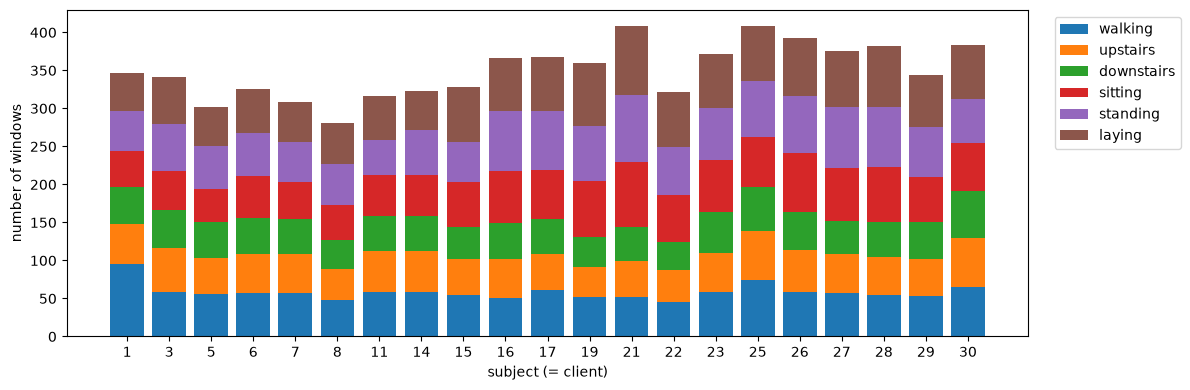

In [ ]:
counts = np.array([[(c[1] == a).sum().item() for a in range(6)] for c in clients])  # clients x activities

fig, ax = plt.subplots(figsize=(12, 4))
bottom = np.zeros(len(clients))
for a in range(6):
    ax.bar(range(len(clients)), counts[:, a], bottom=bottom, label=ACTIVITIES[a])
    bottom += counts[:, a]
ax.set_xticks(range(len(clients))); ax.set_xticklabels(client_ids)
ax.set_xlabel("subject (= client)"); ax.set_ylabel("number of windows")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Observations (natural split).** Every client holds all six activities in similar proportions, and client sizes are close (281 to 409 windows, 350 on average). The label distribution is therefore almost balanced: the heterogeneity of this split is in the sensor values, because people move differently.

### 1.5 A controllable heterogeneity knob: the Dirichlet split

To study heterogeneity as a variable, all training windows can also be redistributed over 21 clients with a Dirichlet split. For each activity, its windows are shared among clients with proportions drawn from a Dirichlet distribution with parameter `alpha`: **small alpha means each client sees only a few activities** (strong label skew), large alpha means all clients see all activities. A small repair step guarantees that no client ends up with fewer than 10 windows.

In this split a client is no longer one person, because windows of different subjects are mixed.

In [ ]:
def dirichlet_split(labels, n_clients, alpha, seed=0, min_size=10):
    """For each activity, share its windows among clients with Dirichlet proportions.
    Small alpha -> each client sees only a few activities. Large alpha -> all see all."""
    rng = np.random.default_rng(seed)
    idx = [[] for _ in range(n_clients)]
    for c in np.unique(labels):
        ci = np.where(labels == c)[0]
        rng.shuffle(ci)
        p = rng.dirichlet([alpha] * n_clients)
        cuts = (np.cumsum(p) * len(ci)).astype(int)[:-1]
        for i, part in enumerate(np.split(ci, cuts)):
            idx[i] += part.tolist()
    # repair step: at very small alpha some clients get (almost) nothing, so
    # we move a few windows from the biggest client to any client below min_size
    for i in range(n_clients):
        while len(idx[i]) < min_size:
            donor = max(range(n_clients), key=lambda j: len(idx[j]))
            idx[i].append(idx[donor].pop())
    return idx

def make_clients(alpha=None, n_clients=21, seed=SEED):
    """alpha=None -> natural split (one client per person). Otherwise Dirichlet split."""
    if alpha is None:
        return [(x_tr_t[s_tr == k], y_tr_t[s_tr == k]) for k in np.unique(s_tr)]
    parts = dirichlet_split(y_tr, n_clients, alpha, seed)
    return [(x_tr_t[torch.tensor(p, dtype=torch.long)], y_tr_t[torch.tensor(p, dtype=torch.long)]) for p in parts]

Comparison of the four conditions (natural split and three values of alpha):

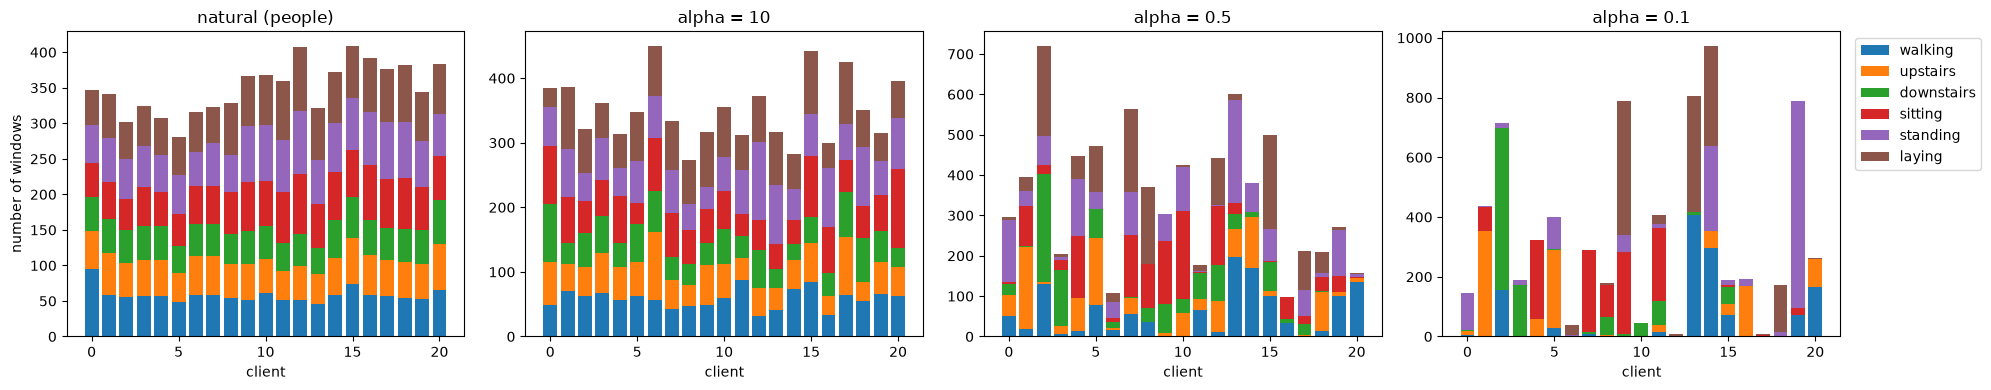

In [ ]:
def plot_clients(cl, ax, title):
    counts = np.array([[(c[1] == a).sum().item() for a in range(6)] for c in cl])
    bottom = np.zeros(len(cl))
    for a in range(6):
        ax.bar(range(len(cl)), counts[:, a], bottom=bottom, label=ACTIVITIES[a])
        bottom += counts[:, a]
    ax.set_title(title); ax.set_xlabel("client")

settings = [("natural (people)", None), ("alpha = 10", 10), ("alpha = 0.5", 0.5), ("alpha = 0.1", 0.1)]
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, a) in zip(axes, settings):
    plot_clients(make_clients(a), ax, name)
axes[0].set_ylabel("number of windows")
axes[3].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

**Observations.** The four conditions used from here on: the natural split (feature shift only), `alpha = 10` (almost IID), `alpha = 0.5` and `alpha = 0.1` (increasing label skew, with each activity concentrated in a few clients).

---
## Step 2: Model, local training and baselines

All clients and the server share the same architecture, so that updates can be averaged. A client's **update** is the difference between its locally trained weights and the global weights it received. A model is handled as one long vector of parameters.

### 2.1 The model

In [ ]:
x_te_t, y_te_t = torch.tensor(X_te), torch.tensor(y_te)

ARCH = dict(h1=128, h2=64)          # hidden layer sizes (changed only in Step 10)

class MLP(nn.Module):
    def __init__(self, d_in=561, n_cls=6):
        super().__init__()
        h1, h2 = ARCH["h1"], ARCH["h2"]
        self.net = nn.Sequential(nn.Linear(d_in, h1), nn.ReLU(),
                                 nn.Linear(h1, h2), nn.ReLU(),
                                 nn.Linear(h2, n_cls))

    def forward(self, x):
        return self.net(x)

n_params = sum(p.numel() for p in MLP().parameters())
print("parameters:", n_params)
print("one full 32-bit update:", n_params * 4 / 1e3, "KB")

parameters: 80582
one full 32-bit update: 322.328 KB


### 2.2 Model to vector and back

In [ ]:
def get_vec(model):
    return parameters_to_vector(model.parameters()).detach().clone()

def set_vec(model, vec):
    vector_to_parameters(vec.clone(), model.parameters())

### 2.3 Evaluation

In [ ]:
@torch.no_grad()
def evaluate(model, x, y):
    model.eval()
    return (model(x).argmax(1) == y).float().mean().item()

def per_subject_acc(model):
    """accuracy on each of the 9 test subjects, to see who the average hides"""
    return {int(k): evaluate(model, x_te_t[s_te == k], y_te_t[s_te == k]) for k in np.unique(s_te)}

### 2.4 Local training (what a client does in one round)

In [ ]:
def local_train(start_vec, x, y, epochs=1, lr=0.05, bs=32):
    """Start from the given weights, train on (x, y), return the new weights."""
    m = MLP(); set_vec(m, start_vec)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    m.train()
    for _ in range(epochs):
        perm = torch.randperm(len(x))
        for i in range(0, len(x), bs):
            b = perm[i:i + bs]
            opt.zero_grad()
            F.cross_entropy(m(x[b]), y[b]).backward()
            opt.step()
    return get_vec(m)

# the "update" a client would send is simply: local_train(...) - start_vec

### 2.5 Baselines: centralized (ceiling) and local-only (floor)

*Centralized:* one model trained on all pooled training data. *Local-only:* one model per client, trained on that client's data alone (the first 5 clients of each condition, one seed). Both are evaluated on the 9 unseen subjects.

In [ ]:
torch.manual_seed(SEED)
init = get_vec(MLP())
EPOCHS = 30

def curve(x, y):
    v, accs = init, []
    for _ in range(EPOCHS):
        v = local_train(v, x, y, epochs=1)
        m = MLP(); set_vec(m, v)
        accs.append(evaluate(m, x_te_t, y_te_t))
    return accs, v

acc_central, v_c = curve(x_tr_t, y_tr_t)
print("centralized (all data pooled):", round(acc_central[-1], 3))
m = MLP(); set_vec(m, v_c)
print("worst unseen subject (centralized):", round(min(per_subject_acc(m).values()), 3))
print()

for name, a in settings:
    cl = make_clients(a)
    finals = [curve(*c)[0][-1] for c in cl[:5]]          # first 5 clients, each training alone
    print(f"{name:18s} local-only accuracy: mean {np.mean(finals):.3f} | worst {min(finals):.3f}")

centralized (all data pooled): 0.945
worst unseen subject (centralized): 0.782

natural (people)   local-only accuracy: mean 0.756 | worst 0.725
alpha = 10         local-only accuracy: mean 0.902 | worst 0.890
alpha = 0.5        local-only accuracy: mean 0.730 | worst 0.592
alpha = 0.1        local-only accuracy: mean 0.382 | worst 0.323


**Results**

| Condition | Local-only accuracy (mean / worst of the first 5 clients) |
|---|---|
| Centralized, all data pooled (ceiling) | 0.945 (worst unseen subject: 0.782) |
| Natural split (one client = one person) | 0.756 / 0.725 |
| Dirichlet alpha = 10 | 0.902 / 0.890 |
| Dirichlet alpha = 0.5 | 0.730 / 0.592 |
| Dirichlet alpha = 0.1 | 0.382 / 0.323 |

Local-only uses only 5 clients and one seed, so small differences are indicative only.

**Two different kinds of heterogeneity.**

1. *Label skew (controlled by alpha).* At alpha = 0.1 a client never sees most activities, so it cannot predict them (accuracy 0.38). Windows are shared out regardless of who recorded them, so people are mixed.
2. *Feature shift (the natural split).* Each client is one person. Activities are balanced, but the sensor values for the same activity differ from person to person.

Evidence that feature shift is real: the natural split (0.756) is much worse than alpha = 10 (0.902), although both give clients about 350 windows on average and alpha = 10 splits each activity almost evenly. At alpha = 10 each client holds a random mix of all subjects, so its model sees many movement styles; in the natural split a client holds one person's data and generalizes poorly to new people.

Both kinds of heterogeneity are kept as experimental conditions. Steps 4 and 5 use the natural split, alpha = 0.5 and alpha = 0.1; from Step 6 on, the natural split and alpha = 0.1.

### 2.6 Why accuracy alone is not enough

Accuracy is a fair starting point because the six activities are nearly balanced, but it has three limits for this project:

1. **It hides who is served badly.** The centralized model has 0.945 accuracy on average, but its worst unseen subject gets 0.782.
2. **It does not show which activities get confused.**
3. **It says nothing about cost.** The research question is about a fixed byte budget.

The function below computes accuracy, macro-F1 (the average of per-activity quality, so a weak activity cannot hide), the worst unseen subject and the spread across subjects, plus the predictions used for a confusion matrix.

In [ ]:
@torch.no_grad()
def full_eval(model):
    model.eval()
    pred = model(x_te_t).argmax(1).numpy()
    subj = [(pred[s_te == k] == y_te[s_te == k]).mean() for k in np.unique(s_te)]
    return dict(acc=(pred == y_te).mean(), macro_f1=f1_score(y_te, pred, average="macro"),
                worst_subject=min(subj), subject_std=np.std(subj)), pred

m = MLP(); set_vec(m, v_c)
res, pred = full_eval(m)
print({k: round(float(v), 3) for k, v in res.items()})
print(ACTIVITIES)
print(confusion_matrix(y_te, pred))   # rows = true activity, columns = predicted

{'acc': 0.945, 'macro_f1': 0.946, 'worst_subject': 0.782, 'subject_std': 0.061}
['walking', 'upstairs', 'downstairs', 'sitting', 'standing', 'laying']
[[491   2   3   0   0   0]
 [ 24 445   2   0   0   0]
 [  7  23 390   0   0   0]
 [  0   1   0 427  63   0]
 [  0   0   0  13 519   0]
 [  0   0   0   0  23 514]]


**Centralized model:** accuracy 0.945, macro-F1 0.946, worst unseen subject 0.782, standard deviation across the 9 subjects 0.061. The most frequent confusions (rows are true activities) are sitting predicted as standing (63 windows), upstairs predicted as walking (24), downstairs predicted as upstairs (23) and laying predicted as standing (23).

---
## Step 3: Plain FedAvg

**FedAvg** is the standard federated baseline. Each round, the server sends the global model to the clients, each client trains it locally, and the server takes the **average of the updates, weighted by each client's number of samples**. Here it is used in its plainest form: honest clients, all 21 clients in every round, full 32-bit updates, no protection against bad clients. Every technique tested later is compared with it.

### 3.1 The aggregation rule

In [ ]:
def fedavg_aggregate(updates, sizes):
    """Weighted mean of the clients' updates: bigger clients count more."""
    w = torch.tensor(sizes, dtype=torch.float32)
    w = w / w.sum()
    return (torch.stack(updates) * w[:, None]).sum(0)

### 3.2 The federated training loop (50 rounds, all clients)

In [ ]:
def run_fedavg(clients, rounds=50, local_epochs=1, lr=0.05, seed=SEED):
    torch.manual_seed(seed)
    g = get_vec(MLP())                  # global model, as one vector
    model = MLP()
    log, bytes_sent = [], 0
    for r in range(1, rounds + 1):
        updates, sizes = [], []
        for x, y in clients:
            new = local_train(g, x, y, epochs=local_epochs, lr=lr)   # client trains locally
            updates.append(new - g)                                  # what it sends back
            sizes.append(len(y))
            bytes_sent += g.numel() * 4                              # 32-bit floats, upload only
        g = g + fedavg_aggregate(updates, sizes)                     # server combines
        set_vec(model, g)
        subj = per_subject_acc(model)
        log.append(dict(round=r, bytes=bytes_sent,
                        acc=evaluate(model, x_te_t, y_te_t), worst=min(subj.values())))
    return log

### 3.3 Run at every heterogeneity level

natural (people) done
alpha = 10 done
alpha = 0.5 done
alpha = 0.1 done


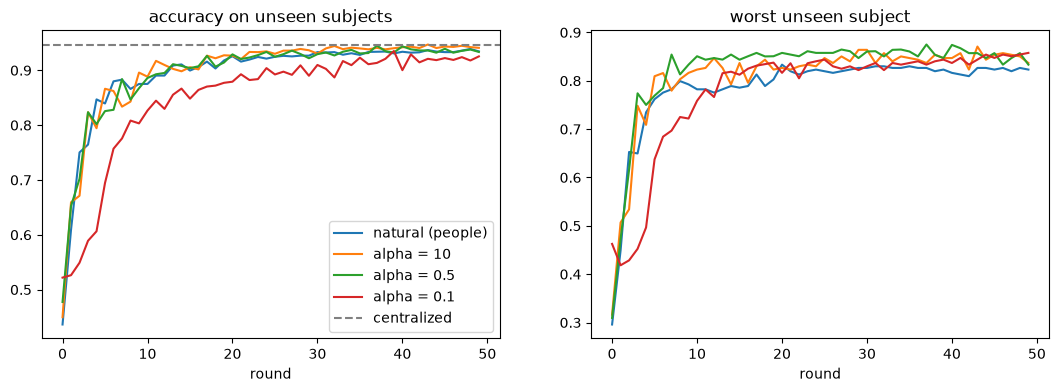

natural (people)   final acc 0.935 | worst subject 0.823 | MB sent 338
alpha = 10         final acc 0.941 | worst subject 0.837 | MB sent 338
alpha = 0.5        final acc 0.933 | worst subject 0.833 | MB sent 338
alpha = 0.1        final acc 0.925 | worst subject 0.858 | MB sent 338


In [ ]:
results = {}
for name, a in settings:            # `settings` comes from the heterogeneity cell
    results[name] = run_fedavg(make_clients(a), rounds=50)
    print(name, "done")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, log in results.items():
    axes[0].plot([d["acc"] for d in log], label=name)
    axes[1].plot([d["worst"] for d in log], label=name)
axes[0].axhline(acc_central[-1], ls="--", c="gray", label="centralized")
axes[0].set_title("accuracy on unseen subjects")
axes[1].set_title("worst unseen subject")
for ax in axes: ax.set_xlabel("round")
axes[0].legend(); plt.show()

for name, log in results.items():
    print(f"{name:18s} final acc {log[-1]['acc']:.3f} | worst subject {log[-1]['worst']:.3f} | MB sent {log[-1]['bytes']/1e6:.0f}")

### 3.4 Rounds and bytes needed to reach 0.90

In [ ]:
def rounds_to_target(log, target=0.90, k=3):
    """First round where accuracy stays >= target for k consecutive rounds
    (k > 1 so a lucky spike on a noisy curve doesn't count)."""
    acc = np.array([d["acc"] for d in log])
    for i in range(len(acc) - k + 1):
        if acc[i:i + k].min() >= target:
            return log[i]
    return None

for name, log in results.items():
    hit = rounds_to_target(log, target=0.90)
    print(f"{name:18s}", f"round {hit['round']}, {hit['bytes']/1e6:.0f} MB" if hit else "never reached 0.90")

natural (people)   round 17, 115 MB
alpha = 10         round 12, 81 MB
alpha = 0.5        round 14, 95 MB
alpha = 0.1        round 34, 230 MB


**Results** (1 seed, 50 rounds, 21 clients, uploads only)

| Condition | Final accuracy | Worst unseen subject | Rounds to reach 0.90 | MB sent to reach 0.90 |
|---|---|---|---|---|
| Natural | 0.935 | 0.823 | 17 | 115 |
| alpha = 10 | 0.941 | 0.837 | 12 | 81 |
| alpha = 0.5 | 0.933 | 0.833 | 14 | 95 |
| alpha = 0.1 | 0.925 | 0.858 | 34 | 230 |

References: centralized 0.945; local-only 0.756 (natural), 0.902 (alpha = 10), 0.730 (alpha = 0.5), 0.382 (alpha = 0.1). 50 rounds cost 338 MB in total (about 6.8 MB per round: 21 clients × 322 KB). "Rounds to reach 0.90" is the first round from which accuracy stays at or above 0.90 for 3 consecutive rounds.

**Findings**

1. **Federation works.** FedAvg ends within about 2 points of the centralized ceiling (0.925 to 0.941 against 0.945) in every condition, far above local-only. At alpha = 0.1, clients alone reach 0.38 while the federation reaches 0.925.
2. **Heterogeneity costs speed more than final accuracy.** Final accuracies lie within 1.6 points of each other, but reaching 0.90 takes 81 MB at alpha = 10, 95 MB at alpha = 0.5, 115 MB in the natural split and 230 MB at alpha = 0.1 (2.8 times the bytes of alpha = 10). The alpha = 0.1 curve is also the noisiest. A likely cause is client drift, where each client's training pulls the model toward its own few activities (not tested directly).
3. **The byte budget is what exposes the differences.** After 50 rounds all conditions look alike, which is why "bytes to reach a target" is a main metric.
4. **No fairness claim from these numbers.** The best worst-subject score at alpha = 0.1 (0.858) comes from one seed and 9 test subjects, and all four values are within a few points.

**Limits:** one seed per condition; only 9 unseen test subjects; no participation limit, compression or attack yet.

---
## Step 4: Partial participation

Only a fraction of the 21 clients (20%, 50% or 100%) takes part in each round, drawn at random each round. The server averages only the updates it receives. Fewer clients per round means fewer bytes per round (20% is about 1.3 MB instead of 6.8 MB), so the fair comparison is **accuracy against bytes spent**, not against rounds. Each run stops when 150 MB have been uploaded. From this step on, 3 seeds are used, each with a different random client split (except for the natural split, which is fixed).

### 4.1 Federated loop with participation and a byte budget

In [ ]:
def run_fl(clients, budget_bytes, participation=1.0, local_epochs=1, lr=0.05, seed=SEED):
    """FedAvg that stops when the byte budget is spent.
    participation = fraction of clients taking part in each round."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    g = get_vec(MLP()); model = MLP()
    n = len(clients)
    k = max(1, round(participation * n))            # clients per round
    log, spent, r = [], 0, 0
    while spent < budget_bytes:
        r += 1
        chosen = rng.choice(n, k, replace=False)    # who is online this round
        updates, sizes = [], []
        for i in chosen:
            x, y = clients[i]
            updates.append(local_train(g, x, y, epochs=local_epochs, lr=lr) - g)
            sizes.append(len(y))
            spent += g.numel() * 4                  # 32-bit upload, as before
        g = g + fedavg_aggregate(updates, sizes)    # average only what arrived
        set_vec(model, g)
        subj = per_subject_acc(model)
        log.append(dict(round=r, bytes=spent, acc=evaluate(model, x_te_t, y_te_t), worst=min(subj.values())))
    return log

### 4.2 Run the grid (participation × heterogeneity × seeds)

In [ ]:
BUDGET = 150e6                      # 150 MB uploaded in total, same for every run
PARTS = [0.2, 0.5, 1.0]
SEEDS = [0, 1, 2]
USED = [s for s in settings if s[0] in ("natural (people)", "alpha = 0.5", "alpha = 0.1")]

R = {}                              # (setting name, participation) -> list of logs, one per seed
for name, a in USED:
    for p in PARTS:
        R[(name, p)] = [run_fl(make_clients(a, seed=s), BUDGET, participation=p, seed=s) for s in SEEDS]
        print(name, f"{int(p*100)}%", "done")

natural (people) 20% done
natural (people) 50% done
natural (people) 100% done
alpha = 0.5 20% done
alpha = 0.5 50% done
alpha = 0.5 100% done
alpha = 0.1 20% done
alpha = 0.1 50% done
alpha = 0.1 100% done


### 4.3 Accuracy against bytes (mean and spread over seeds)

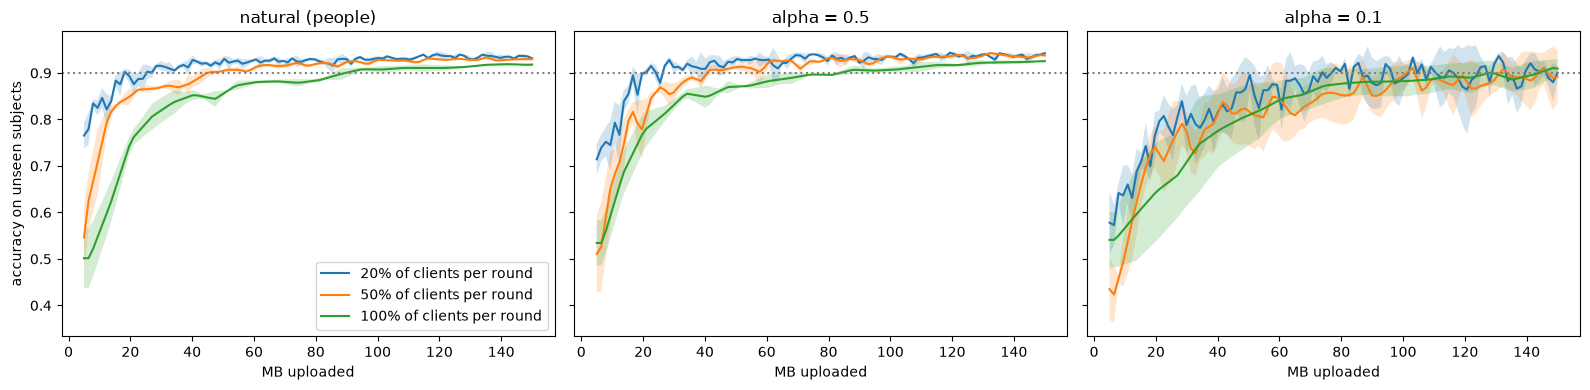

In [ ]:
grid = np.linspace(5e6, BUDGET, 100)
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, _) in zip(axes, USED):
    for p in PARTS:
        curves = np.array([np.interp(grid, [d["bytes"] for d in lg], [d["acc"] for d in lg])
                           for lg in R[(name, p)]])
        m, s = curves.mean(0), curves.std(0)
        ax.plot(grid / 1e6, m, label=f"{int(p*100)}% of clients per round")
        ax.fill_between(grid / 1e6, m - s, m + s, alpha=0.2)
    ax.axhline(0.90, ls=":", c="gray")
    ax.set_title(name); ax.set_xlabel("MB uploaded")
axes[0].set_ylabel("accuracy on unseen subjects"); axes[0].legend()
plt.tight_layout(); plt.show()

### 4.4 Rounds and accuracy at fixed budgets

In [ ]:
print(f"{'setting':18s} {'clients':>8s}  {'reached 0.90':>13s}  {'MB to 0.90':>10s}  {'acc at end':>14s}")
for name, _ in USED:
    for p in PARTS:
        logs = R[(name, p)]
        hits = [rounds_to_target(lg, 0.90) for lg in logs]
        mb = [h["bytes"] / 1e6 for h in hits if h]
        end = [lg[-1]["acc"] for lg in logs]
        mb_txt = f"{np.mean(mb):.0f}" if mb else "-"
        print(f"{name:18s} {int(p*100):7d}%  {len(mb):>10d}/{len(SEEDS)}  {mb_txt:>10s}  {np.mean(end):.3f} +/- {np.std(end):.3f}")

setting             clients   reached 0.90  MB to 0.90      acc at end
natural (people)        20%           3/3          22  0.929 +/- 0.002
natural (people)        50%           3/3          49  0.929 +/- 0.002
natural (people)       100%           3/3          95  0.920 +/- 0.000
alpha = 0.5             20%           3/3          20  0.941 +/- 0.001
alpha = 0.5             50%           3/3          44  0.936 +/- 0.004
alpha = 0.5            100%           3/3         104  0.927 +/- 0.008
alpha = 0.1             20%           2/3          59  0.916 +/- 0.018
alpha = 0.1             50%           2/3          95  0.895 +/- 0.047
alpha = 0.1            100%           1/3          61  0.898 +/- 0.028


In [ ]:
CHECK = [20e6, 50e6, 100e6]

def acc_at(log, b):
    return np.interp(b, [d["bytes"] for d in log], [d["acc"] for d in log])

print(f"{'setting':18s} {'clients':>8s}   " + "   ".join(f"@{int(b/1e6)}MB".ljust(13) for b in CHECK))
for name, _ in USED:
    for p in PARTS:
        cells = []
        for b in CHECK:
            v = [acc_at(lg, b) for lg in R[(name, p)]]
            cells.append(f"{np.mean(v):.3f}+/-{np.std(v):.3f}")
        print(f"{name:18s} {int(p*100):7d}%   " + "   ".join(cells))

setting             clients   @20MB           @50MB           @100MB       
natural (people)        20%   0.885+/-0.018   0.928+/-0.006   0.932+/-0.004
natural (people)        50%   0.850+/-0.015   0.904+/-0.002   0.928+/-0.002
natural (people)       100%   0.750+/-0.018   0.855+/-0.007   0.908+/-0.006
alpha = 0.5             20%   0.898+/-0.005   0.929+/-0.005   0.935+/-0.004
alpha = 0.5             50%   0.787+/-0.056   0.912+/-0.004   0.935+/-0.003
alpha = 0.5            100%   0.772+/-0.040   0.871+/-0.006   0.907+/-0.006
alpha = 0.1             20%   0.772+/-0.029   0.892+/-0.039   0.888+/-0.032
alpha = 0.1             50%   0.738+/-0.043   0.818+/-0.073   0.894+/-0.030
alpha = 0.1            100%   0.643+/-0.106   0.809+/-0.065   0.882+/-0.033


**Results** (accuracy at fixed upload budgets, mean ± std over 3 seeds)

| Condition | Clients per round | @20 MB | @50 MB | @100 MB |
|---|---|---|---|---|
| Natural | 20% | 0.885 ± 0.018 | 0.928 ± 0.006 | 0.932 ± 0.004 |
| Natural | 50% | 0.850 ± 0.015 | 0.904 ± 0.002 | 0.928 ± 0.002 |
| Natural | 100% | 0.750 ± 0.018 | 0.855 ± 0.007 | 0.908 ± 0.006 |
| alpha = 0.5 | 20% | 0.898 ± 0.005 | 0.929 ± 0.005 | 0.935 ± 0.004 |
| alpha = 0.5 | 50% | 0.787 ± 0.056 | 0.912 ± 0.004 | 0.935 ± 0.003 |
| alpha = 0.5 | 100% | 0.772 ± 0.040 | 0.871 ± 0.006 | 0.907 ± 0.006 |
| alpha = 0.1 | 20% | 0.772 ± 0.029 | 0.892 ± 0.039 | 0.888 ± 0.032 |
| alpha = 0.1 | 50% | 0.738 ± 0.043 | 0.818 ± 0.073 | 0.894 ± 0.030 |
| alpha = 0.1 | 100% | 0.643 ± 0.106 | 0.809 ± 0.065 | 0.882 ± 0.033 |

MB needed to reach 0.90 (natural / alpha = 0.5): 22 / 20 MB at 20%, 49 / 44 MB at 50%, 95 / 104 MB at 100%. At alpha = 0.1 this metric is unreliable: the curves hover around 0.90 and not every seed reached it (2/3, 2/3 and 1/3 seeds for 20%, 50% and 100%).

**Findings**

1. **Low participation saves bytes when heterogeneity is mild.** In the natural split and at alpha = 0.5, 20% of the clients reaches 0.90 with about 20 MB, against about 100 MB at full participation (4 to 5 times fewer bytes), and ends higher.
2. **Why:** full participation costs 6.8 MB per round, so 150 MB buys about 22 server updates. At 20% it buys over 100. Many cheap, noisy rounds beat a few expensive ones while the model is still far from converged.
3. **The advantage shrinks as the budget grows** (in the natural split, 13.5 points at 20 MB and 2.4 points at 100 MB). Both methods head for the same ceiling; with a larger budget full participation would be expected to catch up (not tested beyond 150 MB).
4. **At alpha = 0.1** the ordering is the same at small budgets (20% > 50% > 100%), but the spread is large and at 100 MB the three are indistinguishable. There is no sign that low participation hurts under label skew, but 3 seeds cannot confirm it.

**Limits:** 3 seeds (the standard deviation is itself uncertain); participation is random, whereas real clients are not offline at random; small model, easy dataset, 1 local epoch; only uploads are counted (the download of the global model is also cheaper with fewer clients); "50%" is 10 of 21 clients and "20%" is 4 of 21 because of rounding.

---
## Step 5: Compression (quantization)

Each client sends less precise numbers instead of 32-bit floats. It scales its update to fit a small integer range (the largest entry sets the scale), rounds to integers (8-bit or 4-bit), and sends the integers plus one scale value; the server rescales them before averaging. The simulation keeps the numbers as floats and counts the bytes a real message would take. Runs are compared at the same byte budget (60 MB), so cheaper messages mean more rounds.

### 5.1 Quantization and exact byte counting

In [ ]:
def quantize(u, bits, stochastic=False):
    levels = 2 ** (bits - 1) - 1                    # 127 for 8-bit, 7 for 4-bit
    scale = u.abs().max().clamp_min(1e-12)          # largest entry decides the scale
    z = u / scale * levels                          # now in [-levels, levels]
    q = torch.floor(z + torch.rand_like(z)) if stochastic else torch.round(z)
    return q, scale, levels

def dequantize(q, scale, levels):
    return q / levels * scale

def message_bytes(n_params, mode):
    if mode == "none":
        return n_params * 4
    bits = int(mode[1:])
    return n_params * bits / 8 + 4                  # +4 bytes for the scale

def compress_update(u, mode, stochastic=False):
    """client side: returns (what the server reconstructs, bytes sent)"""
    if mode == "none":
        return u, message_bytes(u.numel(), mode)
    q, s, L = quantize(u, int(mode[1:]), stochastic)
    return dequantize(q, s, L), message_bytes(u.numel(), mode)

### 5.2 How much does quantization damage one real update?

In [ ]:
torch.manual_seed(SEED)
g0 = get_vec(MLP())
x0, y0 = make_clients(None)[0]
upd = local_train(g0, x0, y0) - g0                  # one real client update

print(f"{'mode':22s} {'KB sent':>8s} {'relative error':>15s} {'cosine to original':>19s}")
for mode, sto in [("none", False), ("q8", False), ("q4", False), ("q4", True)]:
    rec, nb = compress_update(upd, mode, stochastic=sto)
    err = ((rec - upd).norm() / upd.norm()).item()
    cos = F.cosine_similarity(rec, upd, dim=0).item()
    name = mode + (" (stochastic)" if sto else "")
    print(f"{name:22s} {nb/1e3:8.1f} {err:15.3f} {cos:19.3f}")

mode                    KB sent  relative error  cosine to original
none                      322.3           0.000               1.000
q8                         80.6           0.088               0.996
q4                         40.3           0.836               0.580
q4 (stochastic)            40.3           1.646               0.522


Fraction of the quantized entries that are exactly zero (same update):

In [ ]:
for mode, sto in [("q8", False), ("q4", False), ("q4", True)]:
    rec, _ = compress_update(upd, mode, stochastic=sto)
    print(mode + (" (stochastic)" if sto else ""), "-> entries equal to zero:", f"{(rec == 0).float().mean().item():.1%}")

q8 -> entries equal to zero: 19.6%
q4 -> entries equal to zero: 98.5%
q4 (stochastic) -> entries equal to zero: 88.2%


**One update from client 0 at the initial weights**

| Mode | KB sent | Relative error | Cosine to original | Entries equal to zero |
|---|---|---|---|---|
| 32-bit | 322.3 | 0.000 | 1.000 | |
| 8-bit | 80.6 | 0.088 | 0.996 | 19.6% |
| 4-bit | 40.3 | 0.836 | 0.580 | 98.5% |
| 4-bit, stochastic rounding | 40.3 | 1.646 | 0.522 | 88.2% |

- 8-bit is nearly lossless. A 4-bit update is damaged heavily (the error is 84% of the update's own norm), but it keeps a positive alignment with the original (cosine 0.58). Almost all of its entries become exactly zero, so deterministic 4-bit rounding acts as a crude sparsification that keeps the largest coordinates only.
- Stochastic rounding is unbiased (its noise averages out over clients and rounds) but has higher variance per message: its error is larger than the update itself.
- This is a single update at initialization; the error profile may change later in training. The error of one message turns out to be a poor predictor of training behavior (see the checks at the end of this step).

### 5.3 Federated loop with compression

In [ ]:
def run_fl_c(clients, budget_bytes, participation=1.0, compression="none", stochastic=False,
             local_epochs=1, lr=0.05, seed=SEED):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    g = get_vec(MLP()); model = MLP()
    n = len(clients); k = max(1, round(participation * n))
    log, spent, r = [], 0, 0
    while spent < budget_bytes:
        r += 1
        chosen = rng.choice(n, k, replace=False)
        updates, sizes = [], []
        for i in chosen:
            x, y = clients[i]
            u = local_train(g, x, y, epochs=local_epochs, lr=lr) - g
            u_hat, nb = compress_update(u, compression, stochastic)   # client compresses, server reconstructs
            updates.append(u_hat); sizes.append(len(y)); spent += nb
        g = g + fedavg_aggregate(updates, sizes)
        set_vec(model, g)
        subj = per_subject_acc(model)
        log.append(dict(round=r, bytes=spent, acc=evaluate(model, x_te_t, y_te_t), worst=min(subj.values())))
    return log

### 5.4 Run the grid (compression × participation × heterogeneity × seeds)

In [ ]:
BUDGET2 = 60e6                       # smaller budget: 4-bit runs need many more rounds
PARTS2 = [0.2, 1.0]
COMPS = ["none", "q8", "q4"]

R2 = {}
for name, a in USED:                 # USED and SEEDS come from Step 4
    for p in PARTS2:
        for c in COMPS:
            R2[(name, p, c)] = [run_fl_c(make_clients(a, seed=s), BUDGET2, p, c, seed=s) for s in SEEDS]
        print(name, f"{int(p*100)}%", "done")

natural (people) 20% done
natural (people) 100% done
alpha = 0.5 20% done
alpha = 0.5 100% done
alpha = 0.1 20% done
alpha = 0.1 100% done


### 5.5 Accuracy against bytes (solid: 20% of clients, dashed: all clients)

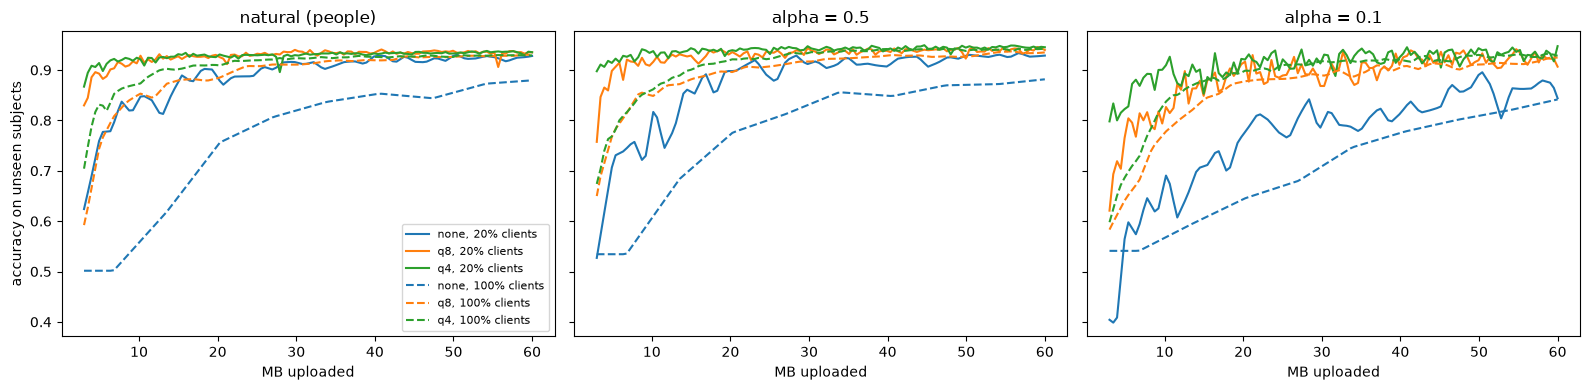

In [ ]:
colors = {"none": "tab:blue", "q8": "tab:orange", "q4": "tab:green"}
styles = {0.2: "-", 1.0: "--"}
grid2 = np.linspace(3e6, BUDGET2, 120)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, _) in zip(axes, USED):
    for p in PARTS2:
        for c in COMPS:
            curves = np.array([np.interp(grid2, [d["bytes"] for d in lg], [d["acc"] for d in lg])
                               for lg in R2[(name, p, c)]])
            ax.plot(grid2 / 1e6, curves.mean(0), color=colors[c], ls=styles[p],
                    label=f"{c}, {int(p*100)}% clients")
    ax.set_title(name); ax.set_xlabel("MB uploaded")
axes[0].set_ylabel("accuracy on unseen subjects"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 5.6 Accuracy at fixed budgets

In [ ]:
CHECK2 = [10e6, 20e6, 40e6]
print(f"{'setting':18s} {'clients':>7s} {'comp':>5s}   " + "   ".join(f"@{int(b/1e6)}MB".ljust(13) for b in CHECK2) + "   end (last 5 rounds)")
for name, _ in USED:
    for p in PARTS2:
        for c in COMPS:
            logs = R2[(name, p, c)]
            cells = [f"{np.mean([acc_at(lg, b) for lg in logs]):.3f}+/-{np.std([acc_at(lg, b) for lg in logs]):.3f}"
                     for b in CHECK2]
            end = [np.mean([d["acc"] for d in lg[-5:]]) for lg in logs]
            print(f"{name:18s} {int(p*100):6d}% {c:>5s}   " + "   ".join(cells) + f"   {np.mean(end):.3f}+/-{np.std(end):.3f}")

setting            clients  comp   @10MB           @20MB           @40MB           end (last 5 rounds)
natural (people)       20%  none   0.842+/-0.012   0.885+/-0.018   0.928+/-0.010   0.924+/-0.003
natural (people)       20%    q8   0.928+/-0.010   0.929+/-0.005   0.936+/-0.003   0.935+/-0.000
natural (people)       20%    q4   0.925+/-0.004   0.928+/-0.004   0.931+/-0.001   0.936+/-0.002
natural (people)      100%  none   0.557+/-0.054   0.750+/-0.018   0.852+/-0.011   0.857+/-0.006
natural (people)      100%    q8   0.852+/-0.011   0.884+/-0.004   0.919+/-0.002   0.929+/-0.002
natural (people)      100%    q4   0.872+/-0.002   0.910+/-0.005   0.926+/-0.001   0.929+/-0.001
alpha = 0.5            20%  none   0.800+/-0.049   0.898+/-0.005   0.907+/-0.023   0.928+/-0.001
alpha = 0.5            20%    q8   0.907+/-0.023   0.925+/-0.010   0.940+/-0.006   0.943+/-0.002
alpha = 0.5            20%    q4   0.926+/-0.009   0.941+/-0.005   0.941+/-0.009   0.945+/-0.004
alpha = 0.5           10

**Results** (60 MB budget, 3 seeds; 4-bit uses nearest rounding here). Mean accuracy at 10 MB:

| Condition | Clients | 32-bit | 8-bit | 4-bit |
|---|---|---|---|---|
| Natural | 20% | 0.842 ± 0.012 | 0.928 ± 0.010 | 0.925 ± 0.004 |
| Natural | 100% | 0.557 ± 0.054 | 0.852 ± 0.011 | 0.872 ± 0.002 |
| alpha = 0.5 | 20% | 0.800 ± 0.049 | 0.907 ± 0.023 | 0.926 ± 0.009 |
| alpha = 0.5 | 100% | 0.606 ± 0.048 | 0.849 ± 0.023 | 0.860 ± 0.004 |
| alpha = 0.1 | 20% | 0.678 ± 0.049 | 0.813 ± 0.054 | 0.906 ± 0.005 |
| alpha = 0.1 | 100% | 0.567 ± 0.078 | 0.775 ± 0.079 | 0.833 ± 0.059 |

**Findings**

1. **Quantization buys a large accuracy gain at a fixed budget.** In the natural split with 20% of the clients, 10 MB gives 0.842 with 32-bit messages and 0.928 / 0.925 with 8-bit / 4-bit messages; with all clients, 0.557 against 0.852 / 0.872.
2. **At equal bytes, 4-bit is equal to or better than 8-bit in all six conditions** at 10 MB. The gap is clear only for alpha = 0.1 with 20% of the clients (0.906 against 0.813) and for the natural split with all clients (0.872 against 0.852); the others are inside the spread. This does not mean 4-bit updates are more accurate: for the same bytes, more rounds helped more than more precision.
3. **Compression and low participation combine.** A round with 4 clients and 4-bit messages costs about 0.16 MB, against 6.8 MB for plain FedAvg (roughly 40 times fewer bytes per round). In the natural split it reaches 0.925 at 10 MB, whereas plain FedAvg needed 115 MB to reach 0.90 (Step 3); at alpha = 0.5, 0.926 at 10 MB against 95 MB.
4. **Compression against fewer clients at similar cost per round** (8-bit with all clients costs 1.7 MB per round, 32-bit with 20% of the clients 1.3 MB): at 10 MB the compressed version is ahead or equal in all three conditions (0.852 against 0.842, 0.849 against 0.800, 0.775 against 0.678). At 20 MB they tie in the natural split and at alpha = 0.5 (0.884 against 0.885; 0.896 against 0.898), and compression stays ahead at alpha = 0.1 (0.877 against 0.772).

**Cautions:** with 60 MB, 32-bit messages with all clients get only about 9 rounds, so the "end" column for that setting is not converged. Only uploads are counted. 3 seeds, with a large spread at alpha = 0.1.

### 5.7 Check: does stochastic rounding help or hurt 4-bit in a real federated run?

In [ ]:
TEST = {}
for name, a in [s for s in USED if s[0] in ("natural (people)", "alpha = 0.1")]:
    for p in [0.2, 1.0]:
        for sto in [False, True]:
            TEST[(name, p, sto)] = [run_fl_c(make_clients(a, seed=s), 40e6, p, "q4", stochastic=sto, seed=s)
                                    for s in SEEDS]
        for sto in [False, True]:
            lg = TEST[(name, p, sto)]
            v = [acc_at(l, 20e6) for l in lg]
            e = [np.mean([d["acc"] for d in l[-5:]]) for l in lg]
            print(f"{name:18s} {int(p*100):3d}% q4 {'stochastic   ' if sto else 'deterministic'}"
                f" @20MB {np.mean(v):.3f}+/-{np.std(v):.3f}   end {np.mean(e):.3f}+/-{np.std(e):.3f}")

natural (people)    20% q4 deterministic @20MB 0.928+/-0.004   end 0.931+/-0.002
natural (people)    20% q4 stochastic    @20MB 0.934+/-0.003   end 0.937+/-0.003
natural (people)   100% q4 deterministic @20MB 0.910+/-0.005   end 0.927+/-0.001
natural (people)   100% q4 stochastic    @20MB 0.922+/-0.001   end 0.934+/-0.002
alpha = 0.1         20% q4 deterministic @20MB 0.902+/-0.032   end 0.922+/-0.006
alpha = 0.1         20% q4 stochastic    @20MB 0.929+/-0.007   end 0.924+/-0.006
alpha = 0.1        100% q4 deterministic @20MB 0.897+/-0.026   end 0.920+/-0.014
alpha = 0.1        100% q4 stochastic    @20MB 0.906+/-0.022   end 0.927+/-0.009


**Deterministic against stochastic rounding for 4-bit** (40 MB budget, 3 seeds)

| Condition | Clients | @20 MB deterministic | @20 MB stochastic | End deterministic | End stochastic |
|---|---|---|---|---|---|
| Natural | 20% | 0.928 ± 0.004 | 0.934 ± 0.003 | 0.931 ± 0.002 | 0.937 ± 0.003 |
| Natural | 100% | 0.910 ± 0.005 | 0.922 ± 0.001 | 0.927 ± 0.001 | 0.934 ± 0.002 |
| alpha = 0.1 | 20% | 0.902 ± 0.032 | 0.929 ± 0.007 | 0.922 ± 0.006 | 0.924 ± 0.006 |
| alpha = 0.1 | 100% | 0.897 ± 0.026 | 0.906 ± 0.022 | 0.920 ± 0.014 | 0.927 ± 0.009 |

("End" is the mean accuracy of the last 5 rounds.) Stochastic rounding was better in all 8 comparisons, by 0.2 to 2.7 points; at alpha = 0.1 the gaps are inside the spread. This goes against the single-update check, where stochastic rounding had the larger error (1.646 against 0.836).

*Hypothesis (not tested):* deterministic rounding is biased, since small entries are always rounded to zero and a small but consistent change is lost every round, while stochastic rounding is unbiased and its extra noise averages out over many rounds and clients. The lesson is that the error of one message is a misleading way to judge a compression method: what counts is the behavior of training.

**Decision:** 4-bit messages use stochastic rounding from Step 8 on.

### 5.8 Check: same number of rounds instead of same bytes (20% of clients)

In [ ]:
def acc_at_round(log, r):
    return log[min(r, len(log)) - 1]["acc"]

for name in ["natural (people)", "alpha = 0.1"]:
    for r in [10, 30]:
        print(name, f"| after {r} rounds (20% of clients):")
        for c in ["none", "q8", "q4"]:
            v = [acc_at_round(lg, r) for lg in R2[(name, 0.2, c)]]
            print(f"   {c:5s} {np.mean(v):.3f} +/- {np.std(v):.3f}")

natural (people) | after 10 rounds (20% of clients):
   none  0.807 +/- 0.047
   q8    0.806 +/- 0.047
   q4    0.812 +/- 0.032
natural (people) | after 30 rounds (20% of clients):
   none  0.912 +/- 0.016
   q8    0.911 +/- 0.016
   q4    0.908 +/- 0.013
alpha = 0.1 | after 10 rounds (20% of clients):
   none  0.650 +/- 0.069
   q8    0.653 +/- 0.072
   q4    0.690 +/- 0.040
alpha = 0.1 | after 30 rounds (20% of clients):
   none  0.795 +/- 0.067
   q8    0.792 +/- 0.068
   q4    0.823 +/- 0.056


| Condition | Rounds | 32-bit | 8-bit | 4-bit |
|---|---|---|---|---|
| Natural | 10 | 0.807 ± 0.047 | 0.806 ± 0.047 | 0.812 ± 0.032 |
| Natural | 30 | 0.912 ± 0.016 | 0.911 ± 0.016 | 0.908 ± 0.013 |
| alpha = 0.1 | 10 | 0.650 ± 0.069 | 0.653 ± 0.072 | 0.690 ± 0.040 |
| alpha = 0.1 | 30 | 0.795 ± 0.067 | 0.792 ± 0.068 | 0.823 ± 0.056 |

**Conclusion.** At an equal number of rounds, quantization costs no measurable accuracy here (8-bit is identical to 32-bit; 4-bit is equal or slightly ahead, within noise). The gain at equal bytes therefore comes from rounds per byte: a 4-bit round costs 1/8 of a 32-bit round. *Not tested:* why 4-bit training is not hurt even though a single 4-bit update is badly damaged.

---
## Step 6: Corrupted clients against plain FedAvg

Until now every client was honest. From here on, **2 of the 21 clients (10%) are corrupted** ("liars" in the tables and plots): a fixed set per seed, chosen at random. In the main attack, a **sign flip with strength `s`**, the client trains normally and then sends `-s` times its honest update (a broken or sabotaging device). The attack strength is written `x1`, `x3`, `x10`...

Why this hurts a plain average: with all clients speaking, 19 honest updates and 2 corrupted ones are averaged with weights proportional to data size. At `x10` the two corrupted updates carry about as much weight as 20 honest ones, so they can outvote them.

The loop below also implements two other attacks, random noise and label flipping, which are used in Step 12.

### 6.1 One corrupted value against four honest ones

In [ ]:
honest = [torch.tensor([0.10]), torch.tensor([0.12]), torch.tensor([0.09]), torch.tensor([0.11])]
liar = torch.tensor([-5.0])

print("average without the liar:", round(fedavg_aggregate(honest, [1]*4).item(), 3))
print("average with the liar   :", round(fedavg_aggregate(honest + [liar], [1]*5).item(), 3))

average without the liar: 0.105
average with the liar   : -0.916


### 6.2 Federated loop with corrupted clients

In [ ]:
AGGREGATORS = {"fedavg": fedavg_aggregate}      # the robust rules are added in Step 7

def run_fl_a(clients, budget_bytes, participation=1.0, compression="q8", stochastic=False,
             attack_frac=0.0, attack_scale=10, aggregator="fedavg", attack_type="signflip",
             local_epochs=1, lr=0.05, seed=SEED):
    """Federated training that stops when the upload budget is spent.

    A fraction `attack_frac` of the clients is corrupted ("liars"), a fixed set per seed.
    attack_type:
      "signflip"  - the client sends -attack_scale * (its honest update)
      "noise"     - the client sends Gaussian noise with std = attack_scale * std(honest update)
      "labelflip" - the client trains honestly on flipped labels (y -> 5 - y), no amplification
    """
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    n = len(clients); k = max(1, round(participation * n))
    n_bad = round(attack_frac * n)                                   # 10% of 21 -> 2 liars
    bad = set(np.random.default_rng(1000 + seed).choice(n, n_bad, replace=False).tolist()) if n_bad else set()
    g = get_vec(MLP()); model = MLP()
    log, spent, r = [], 0, 0
    while spent < budget_bytes:
        r += 1
        chosen = rng.choice(n, k, replace=False)
        updates, sizes = [], []
        for i in chosen:
            x, y = clients[i]
            is_bad = int(i) in bad
            if is_bad and attack_type == "labelflip":
                y = 5 - y                                            # trains honestly, on wrong labels
            u = local_train(g, x, y, epochs=local_epochs, lr=lr) - g
            if is_bad and attack_type == "signflip":
                u = -attack_scale * u                                # opposite and louder
            elif is_bad and attack_type == "noise":
                u = attack_scale * u.std() * torch.randn_like(u)     # random noise
            u_hat, nb = compress_update(u, compression, stochastic)
            updates.append(u_hat); sizes.append(len(y)); spent += nb
        g = g + AGGREGATORS[aggregator](updates, sizes)
        set_vec(model, g)
        subj = per_subject_acc(model)
        log.append(dict(round=r, bytes=spent, acc=evaluate(model, x_te_t, y_te_t), worst=min(subj.values()),
                        nan=bool(torch.isnan(g).any()), maxw=float(g.abs().max())))
    return log

### 6.3 Run with and without corrupted clients (8-bit, 40 MB, x10, plain FedAvg)

In [ ]:
ATTACK_SCALE = 10
BUDGET3 = 40e6
SETS3 = [s for s in USED if s[0] in ("natural (people)", "alpha = 0.1")]

R3 = {}
for name, a in SETS3:
    for p in [0.2, 1.0]:
        for frac in [0.0, 0.1]:
            R3[(name, p, frac)] = [run_fl_a(make_clients(a, seed=s), BUDGET3, p, "q8",
                                            attack_frac=frac, attack_scale=ATTACK_SCALE, seed=s)
                                   for s in SEEDS]
        print(name, f"{int(p*100)}%", "done")

natural (people) 20% done
natural (people) 100% done
alpha = 0.1 20% done
alpha = 0.1 100% done


### 6.4 Accuracy against bytes (blue: no liars, red: 10% liars; solid: 20% of clients, dashed: all clients)

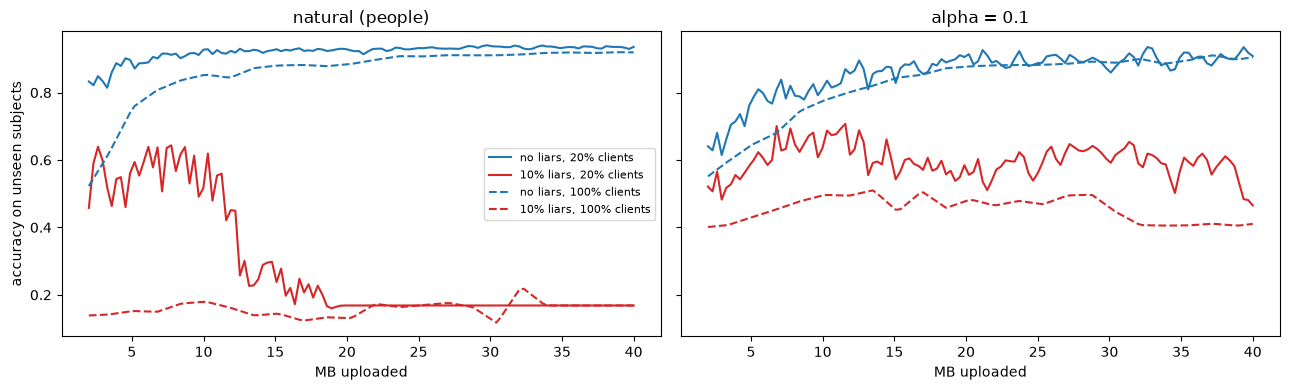

In [ ]:
grid3 = np.linspace(2e6, BUDGET3, 120)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (name, _) in zip(axes, SETS3):
    for p, ls in [(0.2, "-"), (1.0, "--")]:
        for frac, col, lab in [(0.0, "tab:blue", "no liars"), (0.1, "tab:red", "10% liars")]:
            curves = np.array([np.interp(grid3, [d["bytes"] for d in lg], [d["acc"] for d in lg])
                               for lg in R3[(name, p, frac)]])
            ax.plot(grid3 / 1e6, curves.mean(0), color=col, ls=ls, label=f"{lab}, {int(p*100)}% clients")
    ax.set_title(name); ax.set_xlabel("MB uploaded")
axes[0].set_ylabel("accuracy on unseen subjects"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 6.5 Accuracy at the end of the run

In [ ]:
print(f"{'setting':18s} {'clients':>7s}   {'no liars':>15s}   {'10% liars':>15s}   {'drop':>6s}")
for name, _ in SETS3:
    for p in [0.2, 1.0]:
        e = {f: [np.mean([d["acc"] for d in lg[-5:]]) for lg in R3[(name, p, f)]] for f in (0.0, 0.1)}
        print(f"{name:18s} {int(p*100):6d}%   {np.mean(e[0.0]):.3f}+/-{np.std(e[0.0]):.3f}"
              f"   {np.mean(e[0.1]):.3f}+/-{np.std(e[0.1]):.3f}   {np.mean(e[0.0]) - np.mean(e[0.1]):6.3f}")

setting            clients          no liars         10% liars     drop
natural (people)       20%   0.934+/-0.003   0.168+/-0.000    0.766
natural (people)      100%   0.919+/-0.001   0.168+/-0.000    0.750
alpha = 0.1            20%   0.920+/-0.010   0.491+/-0.311    0.430
alpha = 0.1           100%   0.900+/-0.023   0.408+/-0.339    0.492


**Main result** (x10 sign flip, mean accuracy over the last 5 rounds, ± std over 3 seeds)

| Condition | Clients per round | No liars | 10% liars | Drop |
|---|---|---|---|---|
| Natural | 20% | 0.934 ± 0.003 | 0.168 ± 0.000 | 0.766 |
| Natural | 100% | 0.919 ± 0.001 | 0.168 ± 0.000 | 0.750 |
| alpha = 0.1 | 20% | 0.920 ± 0.010 | 0.491 ± 0.311 | 0.430 |
| alpha = 0.1 | 100% | 0.900 ± 0.023 | 0.408 ± 0.339 | 0.492 |

Two corrupted clients out of 21 break plain FedAvg: a total collapse in the natural split and a large, very variable loss at alpha = 0.1. Plain FedAvg has no defense. This is the damage that robust aggregation (Step 7) has to reduce.

At 20% participation about 65% of the rounds contain no corrupted client, and both corrupted clients are present in only about 3% of them; the natural-split run nevertheless collapses, between about 10 and 20 MB in the plot. With all clients, both corrupted clients speak in every round and the run is broken from the start.

### 6.6 What does the accuracy 0.168 mean?

In [ ]:
print(ACTIVITIES)
print(np.round(np.bincount(y_te) / len(y_te), 3))   # share of each activity in the test set

['walking', 'upstairs', 'downstairs', 'sitting', 'standing', 'laying']
[0.168 0.16  0.143 0.167 0.181 0.182]


The share of each activity in the test set (above) shows that walking is 16.8% of it, which is exactly the accuracy of every collapsed run. A model that answers "walking" for every window scores 0.168, and any constant answer scores between 0.143 and 0.182. So 0.168 is the floor of a model that has stopped working. That the collapsed models really answer "walking" for everything was not verified (the accuracy equals that share, which is consistent with it but not a proof).

### 6.7 Why is alpha = 0.1 so variable? Size of the corrupted clients' datasets

In [ ]:
for name, a in SETS3:
    for s in SEEDS:
        cl = make_clients(a, seed=s)
        n = len(cl)
        bad = np.random.default_rng(1000 + s).choice(n, round(0.1 * n), replace=False)
        print(f"{name:18s} seed {s} | liar sizes: {[len(cl[i][1]) for i in bad]} | average client: {int(np.mean([len(c[1]) for c in cl]))}")

natural (people)   seed 0 | liar sizes: [308, 368] | average client: 350
natural (people)   seed 1 | liar sizes: [382, 408] | average client: 350
natural (people)   seed 2 | liar sizes: [408, 323] | average client: 350
alpha = 0.1        seed 0 | liar sizes: [324, 45] | average client: 350
alpha = 0.1        seed 1 | liar sizes: [76, 10] | average client: 350
alpha = 0.1        seed 2 | liar sizes: [1062, 518] | average client: 350


### 6.8 Accuracy without and with liars, per seed, against the liars' share of the data

In [ ]:
print(f"{'setting':18s} {'clients':>7s} {'seed':>4s}  {'liar share':>10s}  {'x10 vs honest':>14s}   acc: no liars -> 10% liars")
for name, a in SETS3:
    for p in [0.2, 1.0]:
        for j, s in enumerate(SEEDS):
            cl = make_clients(a, seed=s); n = len(cl)
            bad = np.random.default_rng(1000 + s).choice(n, round(0.1 * n), replace=False)
            share = sum(len(cl[i][1]) for i in bad) / sum(len(c[1]) for c in cl)
            end = lambda key: np.mean([d["acc"] for d in R3[key][j][-5:]])
            print(f"{name:18s} {int(p*100):6d}% {s:4d}  {share:10.1%}  {10*share:5.2f} vs {1-share:4.2f}   "
                  f"{end((name, p, 0.0)):.3f} -> {end((name, p, 0.1)):.3f}")

setting            clients seed  liar share   x10 vs honest   acc: no liars -> 10% liars
natural (people)       20%    0        9.2%   0.92 vs 0.91   0.931 -> 0.168
natural (people)       20%    1       10.7%   1.07 vs 0.89   0.938 -> 0.168
natural (people)       20%    2        9.9%   0.99 vs 0.90   0.934 -> 0.168
natural (people)      100%    0        9.2%   0.92 vs 0.91   0.920 -> 0.168
natural (people)      100%    1       10.7%   1.07 vs 0.89   0.918 -> 0.168
natural (people)      100%    2        9.9%   0.99 vs 0.90   0.918 -> 0.168
alpha = 0.1            20%    0        5.0%   0.50 vs 0.95   0.912 -> 0.393
alpha = 0.1            20%    1        1.2%   0.12 vs 0.99   0.915 -> 0.910
alpha = 0.1            20%    2       21.5%   2.15 vs 0.79   0.934 -> 0.168
alpha = 0.1           100%    0        5.0%   0.50 vs 0.95   0.880 -> 0.168
alpha = 0.1           100%    1        1.2%   0.12 vs 0.99   0.887 -> 0.888
alpha = 0.1           100%    2       21.5%   2.15 vs 0.79   0.933 -> 0.168

Liar dataset sizes (windows), average client = 350:

- Natural: seed 0 [308, 368], seed 1 [382, 408], seed 2 [408, 323] (similar for every seed).
- alpha = 0.1: seed 0 [324, 45], seed 1 [76, 10], seed 2 [1062, 518] (very different).

Accuracy with all clients, without liars → with liars (x10):

| Condition | Seed | Liars' share of the data | Accuracy |
|---|---|---|---|
| Natural | 0 | 9.2% | 0.920 → 0.168 |
| Natural | 1 | 10.7% | 0.918 → 0.168 |
| Natural | 2 | 9.9% | 0.918 → 0.168 |
| alpha = 0.1 | 0 | 5.0% | 0.880 → 0.168 |
| alpha = 0.1 | 1 | 1.2% | 0.887 → 0.888 |
| alpha = 0.1 | 2 | 21.5% | 0.933 → 0.168 |

1. **The more data the corrupted clients hold, the worse the damage.** FedAvg weights clients by data size. This explains the huge spread at alpha = 0.1: the three seeds have very different liar sizes and end unharmed, collapsed and collapsed.
2. **The outcome at x10 is close to all or nothing:** runs end unharmed or at 0.168. Only one run ended in between (0.393: alpha = 0.1, seed 0, 20% participation, where the liars speak in only some rounds).
3. **A simple rule of thumb is too optimistic.** The liars outvote the honest clients when strength × (their data share) exceeds the honest share, i.e. for a share above 1/(1 + 10) = 9.1% at x10. Seed 0 at alpha = 0.1 collapsed at 5.0%, so the real break point at x10 lies between 1.2% and 5.0%. Possible reason (untested): under non-IID data honest updates partly cancel each other, while the flipped updates of the liars point consistently the wrong way.
4. All natural-split runs lie above the 9.1% line, so they cannot say where that split would break. A sweep over the attack strength can (next cell).
5. Which liars are drawn changes both their data size and the classes they hold, so the effect of "what the liars know" is not separated from the effect of their size.

### 6.9 Attack strength sweep (8-bit, all clients, 20 MB, 10% liars)

In [ ]:
SCALES = [1, 3, 5, 10]
print(f"{'setting':18s} " + "  ".join(f"x{sc}".rjust(13) for sc in SCALES))
for name, a in SETS3:
    row = []
    for sc in SCALES:
        e = [np.mean([d["acc"] for d in run_fl_a(make_clients(a, seed=s), 20e6, 1.0, "q8",
                    attack_frac=0.1, attack_scale=sc, seed=s)[-5:]]) for s in SEEDS]
        row.append(f"{np.mean(e):.3f}+/-{np.std(e):.3f}")
    print(f"{name:18s} " + "  ".join(r.rjust(13) for r in row))

setting                       x1             x3             x5            x10
natural (people)   0.861+/-0.012  0.797+/-0.014  0.644+/-0.051  0.134+/-0.045
alpha = 0.1        0.705+/-0.124  0.666+/-0.145  0.543+/-0.273  0.481+/-0.274


Mean accuracy over the last 5 rounds. Reference without liars at 20 MB (Step 5, 8-bit, all clients): 0.884 (natural) and 0.877 (alpha = 0.1).

| Condition | x1 | x3 | x5 | x10 |
|---|---|---|---|---|
| Natural | 0.861 ± 0.012 | 0.797 ± 0.014 | 0.644 ± 0.051 | 0.134 ± 0.045 |
| alpha = 0.1 | 0.705 ± 0.124 | 0.666 ± 0.145 | 0.543 ± 0.273 | 0.481 ± 0.274 |

1. **Natural split:** the damage grows with the attack strength and breaks between x5 and x10. This fits the rule of thumb of the previous section: the liars win at a strength of about (1 − share) / share, which is 8 to 10 for shares of 9.2% to 10.7%. It is tested only on the natural split, where the liar shares are almost the same for every seed.
2. **alpha = 0.1:** even x1, a plain sign flip with no amplification, costs about 17 points, with a large spread. Possible reason (untested): under label skew honest updates partly cancel each other while a liar's flipped update pulls consistently the wrong way.
3. The x10 damage is therefore a feature of the strength axis: across strengths the natural split degrades gradually, then collapses.
4. In the natural split at x10, the average (0.134) is below the lowest accuracy a constant answer can get (0.143), so not every collapsed run is a constant model. The diagnostic below shows why: at this budget (about 12 rounds) the model is still in an "anti-learning" phase.

### 6.10 Diagnostic: what does a collapsing run look like? (natural, all clients, 8-bit, x10, seed 0, first 12 rounds)

In [ ]:
lg = run_fl_a(make_clients(None), 20e6, 1.0, "q8", attack_frac=0.1, attack_scale=10, seed=0)
print("round  acc    has_nan  largest weight")
for d in lg[:12]:
    print(f"{d['round']:5d}  {d['acc']:.3f}  {str(d['nan']):7s}  {d['maxw']:.2e}")

round  acc    has_nan  largest weight
    1  0.131  False    1.28e-01
    2  0.126  False    1.39e-01
    3  0.115  False    1.54e-01
    4  0.112  False    1.75e-01
    5  0.101  False    1.96e-01
    6  0.130  False    2.17e-01
    7  0.108  False    2.39e-01
    8  0.117  False    2.78e-01
    9  0.111  False    3.02e-01
   10  0.116  False    3.48e-01
   11  0.190  False    3.96e-01
   12  0.185  False    4.50e-01


- The weights contain no NaN and stay small (largest weight 0.13 at round 1, 0.45 at round 12), so the collapse is not a numerical blow-up. There is no honest-run reference for the largest weight, so it cannot be said whether 0.45 is large.
- Accuracy is 0.10 to 0.13 for the first 10 rounds, lower than the accuracy of any constant answer (0.143 or more). The model is not constant: the flipped, amplified updates push it to learn the opposite of the task. It then rises to 0.190 and 0.185 at rounds 11 and 12, above the best constant answer (0.182).
- Not checked: that runs ending at exactly 0.168 (after about 24 rounds) answer "walking" for every window.

---
## Step 7: Robust aggregation

Instead of averaging all updates, the server uses a rule that cannot be dragged away by a few extreme values. For every coordinate of the model separately:

- **Median:** take the middle value across clients.
- **Trimmed mean:** discard the highest and lowest values, then average the rest (3 values at each end for 21 clients, 1 for 4 clients).

Both ignore dataset sizes. The trimmed mean is told the share of corrupted clients (10%); the median has no such parameter. With 4 clients per round both rules average the two middle values, so they are the same rule.

### 7.1 The same tiny example with the three rules

In [ ]:
honest = [torch.tensor([0.10]), torch.tensor([0.12]), torch.tensor([0.09]), torch.tensor([0.11])]
liar = torch.tensor([-5.0])
X = torch.stack(honest + [liar])

print("plain average :", round(X.mean(0).item(), 3))
print("median        :", round(X.median(dim=0).values.item(), 3))
srt = X.sort(dim=0).values                          # sorted: -5.0, 0.09, 0.10, 0.11, 0.12
print("trimmed mean (drop 1 lowest, 1 highest):", round(srt[1:-1].mean(0).item(), 3))

plain average : -0.916
median        : 0.1
trimmed mean (drop 1 lowest, 1 highest): 0.1


### 7.2 The two new rules, plugged into the training loop

In [ ]:
def median_aggregate(updates, sizes=None):
    return torch.stack(updates).quantile(0.5, dim=0)

def trimmed_mean_aggregate(updates, sizes=None, trim=0.1):
    k = len(updates)
    t = min(math.ceil(trim * k), (k - 1) // 2)       # how many values to drop at EACH end
    srt = torch.stack(updates).sort(dim=0).values
    return srt[t:k - t].mean(0)

AGGREGATORS["median"] = median_aggregate             # the dict defined in Step 6
AGGREGATORS["trimmed"] = trimmed_mean_aggregate

for k in [4, 21]:
    print(f"{k} clients per round -> the trimmed mean drops", min(math.ceil(0.1 * k), (k - 1) // 2), "from each end")

4 clients per round -> the trimmed mean drops 1 from each end
21 clients per round -> the trimmed mean drops 3 from each end


### 7.3 Run the three rules with and without liars (8-bit, x10, 40 MB; FedAvg runs are reused from Step 6)

In [ ]:
AGGS = ["fedavg", "median", "trimmed"]
R4 = {}
for name, a in SETS3:
    for p in [0.2, 1.0]:
        for frac in [0.0, 0.1]:
            R4[(name, p, "fedavg", frac)] = R3[(name, p, frac)]       # reuse the Step 6 runs (same settings)
            for agg in ["median", "trimmed"]:
                R4[(name, p, agg, frac)] = [run_fl_a(make_clients(a, seed=s), BUDGET3, p, "q8",
                                                      attack_frac=frac, attack_scale=ATTACK_SCALE,
                                                      aggregator=agg, seed=s) for s in SEEDS]
        print(name, f"{int(p*100)}%", "done")

natural (people) 20% done
natural (people) 100% done
alpha = 0.1 20% done
alpha = 0.1 100% done


### 7.4 Accuracy at the end of the run

In [ ]:
def end_acc(logs):
    return [np.mean([d["acc"] for d in lg[-5:]]) for lg in logs]

print(f"{'setting':18s} {'clients':>7s} {'rule':>8s}   {'no liars':>14s}   {'10% liars':>14s}   {'drop':>6s}")
for name, _ in SETS3:
    for p in [0.2, 1.0]:
        for agg in AGGS:
            e0, e1 = end_acc(R4[(name, p, agg, 0.0)]), end_acc(R4[(name, p, agg, 0.1)])
            print(f"{name:18s} {int(p*100):6d}% {agg:>8s}   {np.mean(e0):.3f}+/-{np.std(e0):.3f}"
                  f"   {np.mean(e1):.3f}+/-{np.std(e1):.3f}   {np.mean(e0)-np.mean(e1):6.3f}")

setting            clients     rule         no liars        10% liars     drop
natural (people)       20%   fedavg   0.934+/-0.003   0.168+/-0.000    0.766
natural (people)       20%   median   0.935+/-0.003   0.600+/-0.173    0.336
natural (people)       20%  trimmed   0.935+/-0.003   0.564+/-0.197    0.371
natural (people)      100%   fedavg   0.919+/-0.001   0.168+/-0.000    0.750
natural (people)      100%   median   0.902+/-0.003   0.893+/-0.008    0.009
natural (people)      100%  trimmed   0.910+/-0.002   0.898+/-0.007    0.012
alpha = 0.1            20%   fedavg   0.920+/-0.010   0.491+/-0.311    0.430
alpha = 0.1            20%   median   0.904+/-0.012   0.717+/-0.075    0.186
alpha = 0.1            20%  trimmed   0.904+/-0.012   0.768+/-0.039    0.136
alpha = 0.1           100%   fedavg   0.900+/-0.023   0.408+/-0.339    0.492
alpha = 0.1           100%   median   0.482+/-0.052   0.423+/-0.106    0.059
alpha = 0.1           100%  trimmed   0.817+/-0.026   0.792+/-0.041    0.0

### 7.5 Accuracy against bytes (solid: with liars, dotted: no liars)

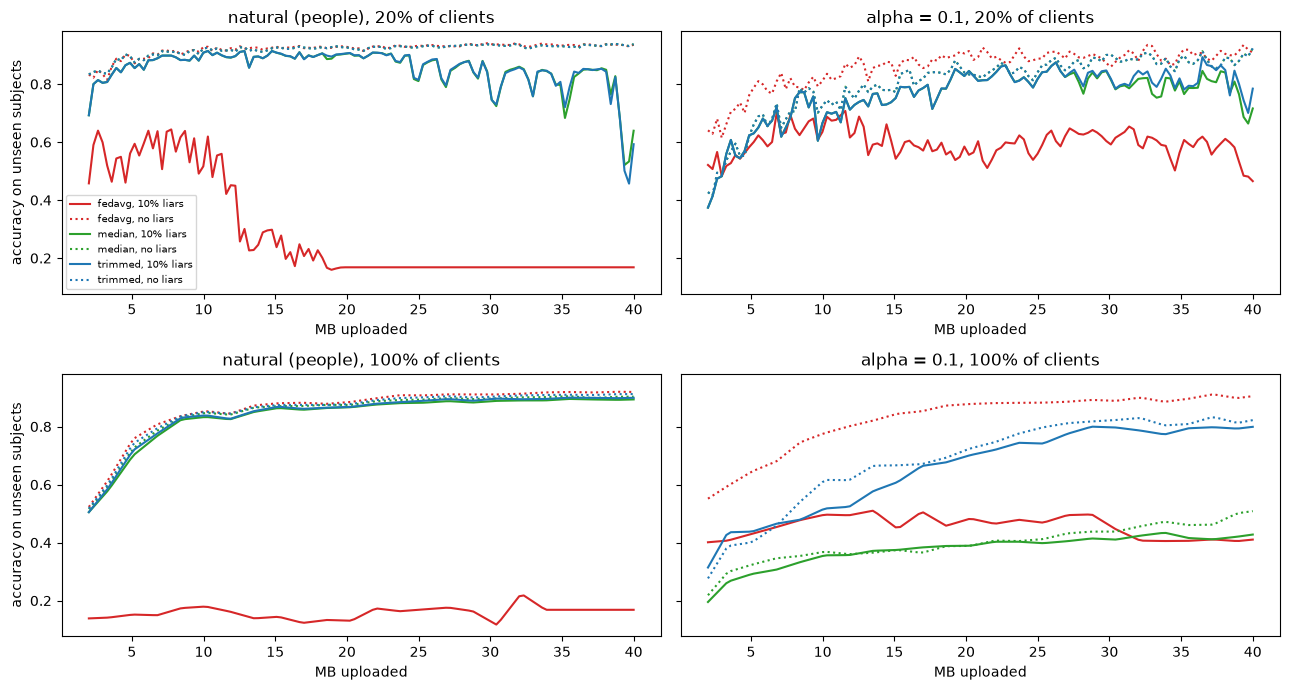

In [ ]:
grid4 = np.linspace(2e6, BUDGET3, 120)
cols = {"fedavg": "tab:red", "median": "tab:green", "trimmed": "tab:blue"}
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=True)
for ri, p in enumerate([0.2, 1.0]):
    for ci, (name, _) in enumerate(SETS3):
        ax = axes[ri, ci]
        for agg in AGGS:
            for frac, ls in [(0.1, "-"), (0.0, ":")]:
                curves = np.array([np.interp(grid4, [d["bytes"] for d in lg], [d["acc"] for d in lg])
                                   for lg in R4[(name, p, agg, frac)]])
                ax.plot(grid4 / 1e6, curves.mean(0), color=cols[agg], ls=ls,
                        label=f"{agg}, {'10% liars' if frac else 'no liars'}")
        ax.set_title(f"{name}, {int(p*100)}% of clients"); ax.set_xlabel("MB uploaded")
axes[0, 0].legend(fontsize=7)
for ri in range(2): axes[ri, 0].set_ylabel("accuracy on unseen subjects")
plt.tight_layout(); plt.show()

**Results** (mean accuracy over the last 5 rounds, ± std over 3 seeds)

| Condition | Clients | Rule | No liars | 10% liars |
|---|---|---|---|---|
| Natural | 100% | FedAvg | 0.919 ± 0.001 | 0.168 ± 0.000 |
| Natural | 100% | median | 0.902 ± 0.003 | 0.893 ± 0.008 |
| Natural | 100% | trimmed | 0.910 ± 0.002 | 0.898 ± 0.007 |
| Natural | 20% | FedAvg | 0.934 ± 0.003 | 0.168 ± 0.000 |
| Natural | 20% | median | 0.935 ± 0.003 | 0.600 ± 0.173 |
| Natural | 20% | trimmed | 0.935 ± 0.003 | 0.564 ± 0.197 |
| alpha = 0.1 | 100% | FedAvg | 0.900 ± 0.023 | 0.408 ± 0.339 |
| alpha = 0.1 | 100% | median | 0.482 ± 0.052 | 0.423 ± 0.106 |
| alpha = 0.1 | 100% | trimmed | 0.817 ± 0.026 | 0.792 ± 0.041 |
| alpha = 0.1 | 20% | FedAvg | 0.920 ± 0.010 | 0.491 ± 0.311 |
| alpha = 0.1 | 20% | median | 0.904 ± 0.012 | 0.717 ± 0.075 |
| alpha = 0.1 | 20% | trimmed | 0.904 ± 0.012 | 0.768 ± 0.039 |

**Findings**

1. **Natural split, all clients:** both rules recover almost everything (0.893 and 0.898 against 0.168 for FedAvg) at a cost of 1 to 2 points without liars (0.902 and 0.910 against 0.919).
2. **alpha = 0.1, all clients: the median fails on its own** (0.482 without any liar, against 0.900 for FedAvg). Hypothesis (untested): under label skew only a few clients push the weights of a given class, and the coordinate-wise median sides with the majority. The curve was still rising at 40 MB, so the median may be slow rather than dead.
3. **The trimmed mean is the only rule that works at alpha = 0.1 with all clients** (0.792 against 0.408 for FedAvg), at about 8 points of cost without liars (0.817 against 0.900). Caveat: it was told the share of corrupted clients.
4. **With 4 clients per round the median and trimmed mean are the same rule.** Their differences in the table (0.600 against 0.564, 0.717 against 0.768) are most likely numerical differences amplified by unstable runs.
5. **At 20% participation the defense holds for a long time, then dips** (see the dip analysis below).
6. The "drop" column of the previous cell compares each rule with itself, so it hides the median's weakness at alpha = 0.1; compare with FedAvg without liars instead.

### 7.6 Check: do 4-bit messages and the median work together? (no liars, 15 MB)

In [ ]:
BUD5 = 15e6
R5 = {}
for name, a in SETS3:
    for p in [0.2, 1.0]:
        for comp, sto in [("q8", False), ("q4", True)]:
            for agg in ["fedavg", "median"]:
                R5[(name, p, comp, agg)] = [run_fl_a(make_clients(a, seed=s), BUD5, p, comp, stochastic=sto,
                                                      attack_frac=0.0, aggregator=agg, seed=s) for s in SEEDS]

print(f"{'setting':18s} {'clients':>7s} {'bits':>5s}   {'fedavg':>14s}   {'median':>14s}")
for name, _ in SETS3:
    for p in [0.2, 1.0]:
        for comp in ["q8", "q4"]:
            f, m = end_acc(R5[(name, p, comp, "fedavg")]), end_acc(R5[(name, p, comp, "median")])
            print(f"{name:18s} {int(p*100):6d}% {comp:>5s}   {np.mean(f):.3f}+/-{np.std(f):.3f}   {np.mean(m):.3f}+/-{np.std(m):.3f}")

setting            clients  bits           fedavg           median
natural (people)       20%    q8   0.924+/-0.003   0.918+/-0.002
natural (people)       20%    q4   0.937+/-0.005   0.930+/-0.003
natural (people)      100%    q8   0.858+/-0.006   0.851+/-0.009
natural (people)      100%    q4   0.907+/-0.002   0.871+/-0.011
alpha = 0.1            20%    q8   0.860+/-0.024   0.781+/-0.044
alpha = 0.1            20%    q4   0.877+/-0.074   0.887+/-0.050
alpha = 0.1           100%    q8   0.798+/-0.068   0.365+/-0.025
alpha = 0.1           100%    q4   0.889+/-0.026   0.245+/-0.031


### 7.7 Check: do the dips at 20% participation follow rounds where both liars speak? (natural, median, x10, 125 rounds)

In [ ]:
name, p = "natural (people)", 0.2
for j, s in enumerate(SEEDS):
    n, k = 21, 4
    bad = set(np.random.default_rng(1000 + s).choice(n, 2, replace=False).tolist())
    rng = np.random.default_rng(s)
    lg = R4[(name, p, "median", 0.1)][j]
    both = [r for r in range(1, len(lg) + 1) if bad <= set(rng.choice(n, k, replace=False).tolist())]
    print(f"seed {s}: {len(lg)} rounds, both liars chosen in rounds {both}")
    for r in both[:6]:
        before = lg[r - 2]["acc"] if r >= 2 else float("nan")
        after = lg[min(r + 1, len(lg) - 1)]["acc"]
        print(f"   round {r}: accuracy before {before:.3f} -> two rounds later {after:.3f}")

seed 0: 125 rounds, both liars chosen in rounds [41, 55, 121, 122]
   round 41: accuracy before 0.918 -> two rounds later 0.888
   round 55: accuracy before 0.925 -> two rounds later 0.906
   round 121: accuracy before 0.921 -> two rounds later 0.428
   round 122: accuracy before 0.481 -> two rounds later 0.742
seed 1: 125 rounds, both liars chosen in rounds [90, 93, 94, 107]
   round 90: accuracy before 0.920 -> two rounds later 0.901
   round 93: accuracy before 0.901 -> two rounds later 0.551
   round 94: accuracy before 0.553 -> two rounds later 0.764
   round 107: accuracy before 0.834 -> two rounds later 0.810
seed 2: 125 rounds, both liars chosen in rounds [6, 73, 77, 83, 102, 109, 119, 122, 123]
   round 6: accuracy before 0.755 -> two rounds later 0.787
   round 73: accuracy before 0.920 -> two rounds later 0.892
   round 77: accuracy before 0.882 -> two rounds later 0.812
   round 83: accuracy before 0.867 -> two rounds later 0.727
   round 102: accuracy before 0.841 -> two r

**4-bit messages and the median** (no liars, 15 MB, 3 seeds, mean of the last 5 rounds)

| Condition | Clients | Bits | FedAvg | Median | Gap |
|---|---|---|---|---|---|
| Natural | 20% | q8 | 0.924 ± 0.003 | 0.918 ± 0.002 | -0.6 |
| Natural | 20% | q4 | 0.937 ± 0.005 | 0.930 ± 0.003 | -0.7 |
| Natural | 100% | q8 | 0.858 ± 0.006 | 0.851 ± 0.009 | -0.7 |
| Natural | 100% | q4 | 0.907 ± 0.002 | 0.871 ± 0.011 | -3.6 |
| alpha = 0.1 | 20% | q8 | 0.860 ± 0.024 | 0.781 ± 0.044 | -7.9 |
| alpha = 0.1 | 20% | q4 | 0.877 ± 0.074 | 0.887 ± 0.050 | +1.0 (noise) |
| alpha = 0.1 | 100% | q8 | 0.798 ± 0.068 | 0.365 ± 0.025 | -43 |
| alpha = 0.1 | 100% | q4 | 0.889 ± 0.026 | 0.245 ± 0.031 | -64 |

- The median fails at alpha = 0.1 with all clients even with 8-bit messages, which confirms the finding above. With all clients, 4-bit messages make it worse (0.365 → 0.245) while FedAvg improves (0.798 → 0.889); with 4 clients per round there is no clear effect.
- This is consistent with the idea that the many exact zeros of quantized 4-bit messages hurt a coordinate-wise median over many clients (a median of 4 values averages two values and rarely returns exactly zero). The zeros inside the median update were not measured, so it is not demonstrated.
- Caveat: 15 MB gives the runs with all clients only about 9 to 18 rounds, so a median that is merely slow would look similar. The trimmed mean was not tested with 4-bit here.

**Dips at 20% participation.** Rounds in which both corrupted clients are among the 4 speakers (expected in about 2.9% of the rounds, i.e. about 3.6 per run): seed 0 [41, 55, 121, 122], seed 1 [90, 93, 94, 107], seed 2 [6, 73, 77, 83, 102, 109, 119, 122, 123]. Accuracy before the round → two rounds later:

- seed 0: 0.918 → 0.888, 0.925 → 0.906, 0.921 → 0.428, 0.481 → 0.742
- seed 1: 0.920 → 0.901, 0.901 → 0.551, 0.553 → 0.764, 0.834 → 0.810
- seed 2 (first 6 events): 0.755 → 0.787, 0.920 → 0.892, 0.882 → 0.812, 0.867 → 0.727, 0.841 → 0.788, 0.817 → 0.712

1. **The large drops come after rounds with both liars**, but not every such round causes one (several change accuracy by 1 to 3 points). Likely mechanism (reasoning, not tested): both liars send the opposite sign, so at a typical coordinate they take the two extreme positions, and the middle pair of a 4-value median contains one liar.
2. **The model often recovers after a single event** (0.553 → 0.764, 0.481 → 0.742). Repeated events seem to accumulate (seed 2); not tested.
3. **The "last 5 rounds" summary is misleading at 20% participation:** in seed 0 the events at rounds 121 and 122 fall inside the last 5 rounds, in seed 1 none do, so the mean of 0.600 ± 0.173 mostly reflects whether a bad round happened near the end, while the model spends most of the run near 0.9. Step 8 therefore summarizes each run over the second half of its rounds.
4. Not checked: seed 2 is shown only for its first 6 events, and dips without a both-liar round were not searched for.

---
## Step 8: Combined experiments

The levers are now combined and every configuration gets the **same 40 MB upload budget**:

- participation: 20% or 100% of the clients per round;
- messages: 8-bit (nearest rounding) or 4-bit (stochastic rounding);
- aggregator: FedAvg, median, trimmed mean (the trimmed mean is skipped at 20% participation, where it equals the median);
- attack: none, x3 or x10 sign flip with 2 of the 21 clients corrupted;
- conditions: natural split and alpha = 0.1; 3 seeds.

Each run is summarized over the **second half of its rounds**: mean accuracy, worst accuracy reached, worst unseen subject, and the MB needed to reach 85% accuracy (first time it holds for 3 rounds). With 40 MB, 8-bit messages with all clients give only about 23 rounds.

### 8.1 Settings and run summary

In [ ]:
SEEDS8 = [0, 1, 2]                 # add seeds here (e.g. [0, 1, 2, 3, 4]); finished runs are cached and skipped
BUDGET8 = 40e6
SETTINGS8 = [("natural (people)", None), ("alpha = 0.1", 0.1)]
PARTS8 = [0.2, 1.0]
COMPS8 = [("q8", False), ("q4", True)]                    # (bits, stochastic rounding)
ATTACKS8 = [("none", 0.0, 0), ("x3", 0.1, 3), ("x10", 0.1, 10)]   # (name, share of liars, strength)
TARGET8 = 0.85                     # for "MB needed to reach this accuracy"

def aggs_for(p):
    # with 4 clients per round the median and trimmed mean are the same rule: run only one
    return ["fedavg", "median"] if p < 0.5 else ["fedavg", "median", "trimmed"]

def summarize(log):
    half = log[len(log) // 2:]
    acc = [d["acc"] for d in half]
    hit = rounds_to_target(log, TARGET8)                  # defined in Step 3
    return dict(mean2=float(np.mean(acc)), worst2=float(np.min(acc)),
                worstsubj=float(np.mean([d["worst"] for d in half])),
                mb_target=hit["bytes"] / 1e6 if hit else float("nan"), rounds=len(log))

### 8.2 Run the grid (finished runs are cached in `step8_results.pkl`)

In [ ]:
FILE = "step8_results.pkl"
R8 = pickle.load(open(FILE, "rb")) if os.path.exists(FILE) else {}
t0 = time.time()

for name, a in SETTINGS8:
    for p in PARTS8:
        for comp, sto in COMPS8:
            for agg in aggs_for(p):
                for atk, frac, sc in ATTACKS8:
                    key = (name, p, comp, agg, atk)
                    R8.setdefault(key, {})
                    for s in SEEDS8:
                        if s not in R8[key]:
                            lg = run_fl_a(make_clients(a, seed=s), BUDGET8, p, comp, stochastic=sto,
                                        attack_frac=frac, attack_scale=sc, aggregator=agg, seed=s)
                            R8[key][s] = summarize(lg)
            pickle.dump(R8, open(FILE, "wb"))
            print(name, f"{int(p*100)}%", comp, "done", f"({(time.time() - t0) / 60:.1f} min)")

natural (people) 20% q8 done (3.4 min)
natural (people) 20% q4 done (11.3 min)
natural (people) 100% q8 done (16.1 min)
natural (people) 100% q4 done (24.9 min)
alpha = 0.1 20% q8 done (29.4 min)
alpha = 0.1 20% q4 done (37.8 min)
alpha = 0.1 100% q8 done (42.3 min)
alpha = 0.1 100% q4 done (49.5 min)


### 8.3 Main tables (columns are the attacks)

In [ ]:
def cell(key, field):
    v = [r[field] for r in R8[key].values()]
    return f"{np.nanmean(v):.3f}+/-{np.nanstd(v):.3f}"

def table(field, title):
    print(title)
    print(f"{'setting':18s} {'cl':>4s} {'bits':>4s} {'rule':>8s}   " + "   ".join(a[0].rjust(13) for a in ATTACKS8))
    for name, _ in SETTINGS8:
        for p in PARTS8:
            for comp, _ in COMPS8:
                for agg in aggs_for(p):
                    row = "   ".join(cell((name, p, comp, agg, a[0]), field).rjust(13) for a in ATTACKS8)
                    print(f"{name:18s} {int(p*100):3d}% {comp:>4s} {agg:>8s}   {row}")
    print()

table("mean2", "MEAN accuracy over the second half of the run (columns = attack)")
table("worst2", "WORST accuracy reached in the second half of the run")
table("worstsubj", "WORST unseen subject (mean over the second half)")

MEAN accuracy over the second half of the run (columns = attack)
setting              cl bits     rule            none              x3             x10
natural (people)    20%   q8   fedavg   0.933+/-0.001   0.459+/-0.170   0.168+/-0.000
natural (people)    20%   q8   median   0.930+/-0.001   0.893+/-0.017   0.825+/-0.049
natural (people)    20%   q4   fedavg   0.935+/-0.001   0.168+/-0.000   0.168+/-0.000
natural (people)    20%   q4   median   0.929+/-0.001   0.899+/-0.013   0.639+/-0.333
natural (people)   100%   q8   fedavg   0.913+/-0.003   0.800+/-0.049   0.169+/-0.005
natural (people)   100%   q8   median   0.898+/-0.005   0.888+/-0.010   0.888+/-0.010
natural (people)   100%   q8  trimmed   0.905+/-0.005   0.893+/-0.009   0.893+/-0.009
natural (people)   100%   q4   fedavg   0.929+/-0.002   0.650+/-0.101   0.168+/-0.000
natural (people)   100%   q4   median   0.895+/-0.003   0.880+/-0.010   0.880+/-0.010
natural (people)   100%   q4  trimmed   0.915+/-0.004   0.906+/-0.007   0.9

### 8.4 MB needed to reach 85% accuracy (seeds that reached it / mean MB)

In [ ]:
print(f"MB needed to reach {TARGET8:.0%} (reached in how many seeds / mean MB)")
print(f"{'setting':18s} {'cl':>4s} {'bits':>4s} {'rule':>8s}   " + "   ".join(a[0].rjust(11) for a in ATTACKS8))
for name, _ in SETTINGS8:
    for p in PARTS8:
        for comp, _ in COMPS8:
            for agg in aggs_for(p):
                out = []
                for a in ATTACKS8:
                    v = [r["mb_target"] for r in R8[(name, p, comp, agg, a[0])].values()]
                    ok = [x for x in v if not np.isnan(x)]
                    out.append(f"{len(ok)}/{len(v)} {np.mean(ok):4.0f}MB".rjust(11) if ok else f"{len(ok)}/{len(v)}    -".rjust(11))
                print(f"{name:18s} {int(p*100):3d}% {comp:>4s} {agg:>8s}   " + "   ".join(out))

MB needed to reach 85% (reached in how many seeds / mean MB)
setting              cl bits     rule          none            x3           x10
natural (people)    20%   q8   fedavg    3/3    3MB    2/3    6MB      0/3    -
natural (people)    20%   q8   median    3/3    3MB    3/3    5MB    3/3    6MB
natural (people)    20%   q4   fedavg    3/3    2MB    2/3    3MB      0/3    -
natural (people)    20%   q4   median    3/3    2MB    3/3    2MB    3/3    2MB
natural (people)   100%   q8   fedavg    3/3   13MB    1/3   22MB      0/3    -
natural (people)   100%   q8   median    3/3   13MB    3/3   15MB    3/3   15MB
natural (people)   100%   q8  trimmed    3/3   13MB    3/3   14MB    3/3   14MB
natural (people)   100%   q4   fedavg    3/3    6MB    1/3   10MB      0/3    -
natural (people)   100%   q4   median    3/3   10MB    3/3   15MB    3/3   15MB
natural (people)   100%   q4  trimmed    3/3    8MB    3/3    8MB    3/3    8MB
alpha = 0.1         20%   q8   fedavg    3/3   13MB    2/3 

### 8.5 Best three configurations in each scenario (by mean accuracy)

In [ ]:
for name, _ in SETTINGS8:
    for atk, _, _ in ATTACKS8:
        rows = []
        for k, d in R8.items():
            if k[0] == name and k[4] == atk:
                rows.append((np.mean([r["mean2"] for r in d.values()]),
                             np.mean([r["worst2"] for r in d.values()]), k))
        rows.sort(reverse=True)
        print(f"{name}, attack = {atk}")
        for m, w, k in rows[:3]:
            print(f"   mean {m:.3f} (worst {w:.3f})  |  {int(k[1]*100)}% of clients, {k[2]}, {k[3]}")

natural (people), attack = none
   mean 0.935 (worst 0.914)  |  20% of clients, q4, fedavg
   mean 0.933 (worst 0.902)  |  20% of clients, q8, fedavg
   mean 0.930 (worst 0.903)  |  20% of clients, q8, median
natural (people), attack = x3
   mean 0.906 (worst 0.897)  |  100% of clients, q4, trimmed
   mean 0.899 (worst 0.814)  |  20% of clients, q4, median
   mean 0.893 (worst 0.564)  |  20% of clients, q8, median
natural (people), attack = x10
   mean 0.906 (worst 0.897)  |  100% of clients, q4, trimmed
   mean 0.893 (worst 0.874)  |  100% of clients, q8, trimmed
   mean 0.888 (worst 0.871)  |  100% of clients, q8, median
alpha = 0.1, attack = none
   mean 0.924 (worst 0.857)  |  20% of clients, q4, fedavg
   mean 0.920 (worst 0.902)  |  100% of clients, q4, fedavg
   mean 0.918 (worst 0.838)  |  20% of clients, q4, median
alpha = 0.1, attack = x3
   mean 0.900 (worst 0.769)  |  20% of clients, q4, median
   mean 0.851 (worst 0.691)  |  20% of clients, q8, median
   mean 0.766 (worst 

**Best configuration per scenario** (by mean accuracy over the second half; worst = worst accuracy reached in that half)

| Scenario | Best configuration | Mean | Worst | MB to 85% |
|---|---|---|---|---|
| Natural, no liars | 20% clients, 4-bit, FedAvg | 0.935 | 0.914 | 2 |
| Natural, x3 | 100%, 4-bit, trimmed mean | 0.906 | 0.897 | 8 |
| Natural, x10 | 100%, 4-bit, trimmed mean | 0.906 | 0.897 | 8 |
| alpha = 0.1, no liars | 20%, 4-bit, FedAvg | 0.924 | 0.857 | 5 |
| alpha = 0.1, x3 | 20%, 4-bit, median | 0.900 | 0.769 | 13 |
| alpha = 0.1, x10 | no clear winner: 20% 8-bit median 0.807 (worst 0.539); 100% 8-bit trimmed 0.777 (worst 0.712); 20% 4-bit median 0.775 (worst 0.612) | | | |

Differences of 1 to 2 points are inside the noise with 3 seeds.

**Findings**

1. **There is no single best configuration:** the best choice depends on whether corrupted clients are present and on how heterogeneous the data is.
2. **Protection costs bytes.** In the natural split, the cheapest unprotected setup (20%, 4-bit, FedAvg, no liars) reaches 85% with 2 MB, the safe setup under x10 (100%, 4-bit, trimmed mean) with 8 MB: about 4 times more.
3. **Low participation is risky under attack.** Natural split, x10, median, 20% of clients: mean 0.825 (8-bit) and 0.639 (4-bit), but the worst accuracy reached is 0.315 and 0.354; with all clients the same rule has a worst accuracy of 0.871 and 0.870. This is consistent with the dip analysis of Step 7.
4. **At alpha = 0.1 the median works at 20% participation and fails with all clients.** With 20% of the clients and x3 it reaches 0.851 (8-bit) and 0.900 (4-bit); with all clients it scores 0.450 and 0.321 even without liars. Hypothesis (untested): a median of 4 values averages the middle two (25% trimmed at each end) while a median of 21 values keeps one (about 48% trimmed at each end), and more trimming throws away more honest information when clients differ. The trimmed mean with all clients (about 14% trimmed) lies in between (0.756 to 0.807). Step 9 tests this directly.
5. **With all clients, each robust rule gives the same result under x3 and x10** (8-bit: median 0.888 and 0.888, trimmed mean 0.893 and 0.893): they use the order of the values and not the size of the extremes. At 20% participation the strength matters (median, 8-bit: 0.893 at x3, 0.825 at x10; 4-bit: 0.899 and 0.639).
6. **4-bit messages made plain FedAvg more fragile under x3 in the natural split** (20% of clients: 0.459 with 8-bit against 0.168 with 4-bit; all clients: 0.800 against 0.650), but not at alpha = 0.1 (0.634 against 0.639 and 0.634 against 0.631). Hypotheses (untested): 4-bit makes twice as many rounds from the same budget, so the corrupted clients get twice as many chances to push; or the rounding noise reduces the model's ability to absorb a bad update.
7. **"MB to 85%" can mislead under attack.** Natural, 20%, 4-bit, median, x10 reaches 85% in 3 of 3 seeds with 2 MB, but its second-half mean is 0.639 and its worst accuracy 0.354: it was knocked down after an early success. Read it together with the second-half tables.
8. **alpha = 0.1 under x10: nothing works well.** The best means (0.775 to 0.807) are about 12 to 15 points below the no-attack level (0.92). The 20% median has the highest mean but a large spread (up to ± 0.145) and a worst accuracy of 0.539 to 0.612; the 8-bit trimmed mean with all clients is steadier (worst 0.712, ± 0.023) but reaches 85% in only 1 of 3 seeds, at 37 MB.
9. **Without liars,** 4-bit FedAvg is the best choice (natural: 0.935 at 20%, 0.929 at 100%; alpha = 0.1: 0.924 and 0.920), as in Step 5. Robust rules cost between 0.3 and 3.4 points in these cases, except for the median at alpha = 0.1 with all clients, which fails.
10. **4-bit and robust rules at alpha = 0.1 with all clients:** 4-bit helps FedAvg (0.920 against 0.893 with 8-bit) but hurts the median (0.321 against 0.450) and the trimmed mean (0.756 against 0.807), consistent with the check in Step 7.

**Limits:** 3 seeds, with large spreads at alpha = 0.1, at 20% participation and for FedAvg under attack (outcomes are close to bimodal); 8-bit against 4-bit at 100% participation partly compares numbers of rounds; the trimmed mean is told the share of liars; one attack type in this grid, the same 2 liars throughout a run, small model, one dataset, uploads only.

---
## Step 9: How much to trim

The trimmed mean has one design parameter: how many values `t` to drop at each end of every coordinate (out of 21 clients). `t = 0` is an unweighted mean, `t = 10` leaves only the middle value, i.e. the median, and Step 8 used `t = 3`. Is the median's failure at alpha = 0.1 a matter of trimming too much? Setup: all clients, 8-bit, 40 MB, x10 sign flip, 2 liars, 3 seeds.

### 9.1 Aggregators indexed by the number of dropped values

In [ ]:
def trimmed_t(t):
    def agg(updates, sizes=None):
        k = len(updates)
        tt = min(t, (k - 1) // 2)                     # never drop more than all but the middle one
        srt = torch.stack(updates).sort(dim=0).values
        return srt[tt:k - tt].mean(0)
    return agg

TS = [0, 1, 2, 3, 5, 7, 10]
for t in TS:
    AGGREGATORS[f"t{t}"] = trimmed_t(t)               # registered in the dict used by run_fl_a

### 9.2 Run the sweep (cached in `trim_sweep.pkl`)

In [ ]:
SWEEP_FILE = "trim_sweep.pkl"
R9 = pickle.load(open(SWEEP_FILE, "rb")) if os.path.exists(SWEEP_FILE) else {}
ATK9 = [("none", 0.0, 0), ("x10", 0.1, 10)]
t0 = time.time()

for name, a in SETTINGS8:                              # natural and alpha = 0.1
    for t in TS:
        for atk, frac, sc in ATK9:
            key = (name, t, atk)
            R9.setdefault(key, {})
            for s in SEEDS8:
                if s not in R9[key]:
                    lg = run_fl_a(make_clients(a, seed=s), BUDGET8, 1.0, "q8",
                                attack_frac=frac, attack_scale=sc, aggregator=f"t{t}", seed=s)
                    R9[key][s] = summarize(lg)
                    pickle.dump(R9, open(SWEEP_FILE, "wb"))
        print(name, f"t = {t} done", f"({(time.time() - t0) / 60:.1f} min)")

natural (people) t = 0 done (1.8 min)
natural (people) t = 1 done (3.3 min)
natural (people) t = 2 done (4.6 min)
natural (people) t = 3 done (6.2 min)
natural (people) t = 5 done (7.9 min)
natural (people) t = 7 done (9.6 min)
natural (people) t = 10 done (11.2 min)
alpha = 0.1 t = 0 done (12.8 min)
alpha = 0.1 t = 1 done (14.1 min)
alpha = 0.1 t = 2 done (15.4 min)
alpha = 0.1 t = 3 done (16.7 min)
alpha = 0.1 t = 5 done (17.9 min)
alpha = 0.1 t = 7 done (19.2 min)
alpha = 0.1 t = 10 done (20.4 min)


### 9.3 Tables (the FedAvg rows come from Step 8)

In [ ]:
if "R8" not in globals():
    R8 = pickle.load(open("step8_results.pkl", "rb"))   # Step 8 results, for the FedAvg reference

def show(field):
    print(f"{field}  (t = values dropped at each end, out of 21 clients)")
    print(f"{'setting':18s} {'t':>3s}   {'no liars':>14s}   {'x10 liars':>14s}")
    for name, _ in SETTINGS8:
        for t in TS:
            row = []
            for atk in ["none", "x10"]:
                v = [r[field] for r in R9[(name, t, atk)].values()]
                row.append(f"{np.mean(v):.3f}+/-{np.std(v):.3f}")
            note = "  <- plain unweighted mean" if t == 0 else "  <- the median" if t == 10 else ""
            print(f"{name:18s} {t:3d}   {row[0]:>14s}   {row[1]:>14s}{note}")
        ref = []
        for atk in ["none", "x10"]:
            v = [r[field] for r in R8[(name, 1.0, "q8", "fedavg", atk)].values()]
            ref.append(f"{np.mean(v):.3f}+/-{np.std(v):.3f}")
        print(f"{name:18s} FedAvg {ref[0]:>14s}   {ref[1]:>14s}   (weighted by data size, Step 8)")
        print()

show("mean2")
show("worst2")

mean2  (t = values dropped at each end, out of 21 clients)
setting              t         no liars        x10 liars
natural (people)     0    0.910+/-0.003    0.156+/-0.011  <- plain unweighted mean
natural (people)     1    0.908+/-0.004    0.695+/-0.047
natural (people)     2    0.906+/-0.005    0.892+/-0.010
natural (people)     3    0.905+/-0.005    0.893+/-0.009
natural (people)     5    0.902+/-0.005    0.891+/-0.009
natural (people)     7    0.900+/-0.005    0.889+/-0.010
natural (people)    10    0.898+/-0.005    0.888+/-0.010  <- the median
natural (people)   FedAvg  0.913+/-0.003    0.169+/-0.005   (weighted by data size, Step 8)

alpha = 0.1          0    0.888+/-0.022    0.168+/-0.001  <- plain unweighted mean
alpha = 0.1          1    0.860+/-0.027    0.562+/-0.281
alpha = 0.1          2    0.838+/-0.024    0.797+/-0.032
alpha = 0.1          3    0.807+/-0.026    0.777+/-0.023
alpha = 0.1          5    0.701+/-0.081    0.639+/-0.052
alpha = 0.1          7    0.572+/-0.074 

### 9.4 Accuracy against the number of dropped values

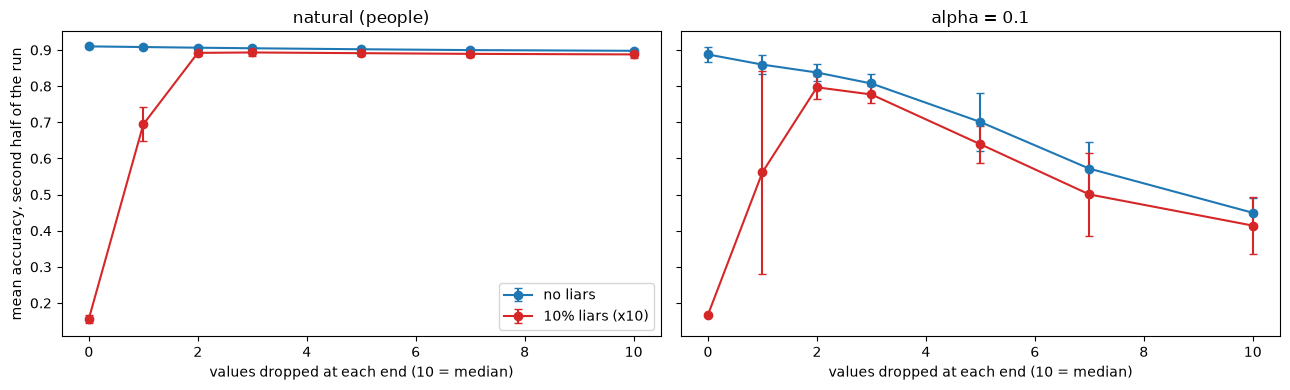

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (name, _) in zip(axes, SETTINGS8):
    for atk, col in [("none", "tab:blue"), ("x10", "tab:red")]:
        m = [np.mean([r["mean2"] for r in R9[(name, t, atk)].values()]) for t in TS]
        s = [np.std([r["mean2"] for r in R9[(name, t, atk)].values()]) for t in TS]
        ax.errorbar(TS, m, yerr=s, color=col, marker="o", capsize=3,
                    label="no liars" if atk == "none" else "10% liars (x10)")
    ax.set_title(name); ax.set_xlabel("values dropped at each end (10 = median)")
axes[0].set_ylabel("mean accuracy, second half of the run"); axes[0].legend()
plt.tight_layout(); plt.show()

**Mean accuracy over the second half** (± std over 3 seeds). Sanity check: the `t = 3` and `t = 10` rows reproduce the trimmed mean and median results of Step 8.

| t | Natural, no liars | Natural, x10 | alpha = 0.1, no liars | alpha = 0.1, x10 |
|---|---|---|---|---|
| 0 | 0.910 ± 0.003 | 0.156 ± 0.011 | 0.888 ± 0.022 | 0.168 ± 0.001 |
| 1 | 0.908 ± 0.004 | 0.695 ± 0.047 | 0.860 ± 0.027 | 0.562 ± 0.281 |
| 2 | 0.906 ± 0.005 | 0.892 ± 0.010 | 0.838 ± 0.024 | 0.797 ± 0.032 |
| 3 | 0.905 ± 0.005 | 0.893 ± 0.009 | 0.807 ± 0.026 | 0.777 ± 0.023 |
| 5 | 0.902 ± 0.005 | 0.891 ± 0.009 | 0.701 ± 0.081 | 0.639 ± 0.052 |
| 7 | 0.900 ± 0.005 | 0.889 ± 0.010 | 0.572 ± 0.074 | 0.500 ± 0.115 |
| 10 (median) | 0.898 ± 0.005 | 0.888 ± 0.010 | 0.450 ± 0.041 | 0.414 ± 0.078 |
| FedAvg (weighted) | 0.913 ± 0.003 | 0.169 ± 0.005 | 0.893 ± 0.027 | 0.441 ± 0.312 |

**Findings**

1. **Natural split:** with 2 liars, `t = 2` is enough (0.892, against 0.695 at `t = 1`); beyond that the curve is flat, and trimming costs about 1 point without liars.
2. **alpha = 0.1, no liars:** accuracy falls at every step of `t` (0.888 → 0.450). This agrees with the Step 8 hypothesis that more trimming throws away more honest information when clients differ; the sweep shows the trend, not the mechanism. The unweighted mean (`t = 0`, 0.888) is close to FedAvg (0.893), so weighting by data size is not what drives the decline.
3. **alpha = 0.1, x10:** the best result is at `t = 2`, which is the number of liars (0.797 ± 0.032, worst accuracy 0.737 ± 0.016). Its 2-point advantage over `t = 3` is about one standard deviation, so it is a lead and not a result. `t = 1` is not enough (0.562 ± 0.281, with a large spread across seeds).
4. **Trade-off:** protection needs `t` to be at least the number of liars, and every extra step costs accuracy when clients differ. The trimmed mean here is told the true number of liars; a real server does not know it. Too low a `t` gives no protection, too high a `t` loses accuracy (cheap in the natural split, expensive at alpha = 0.1).
5. **Consistent with Step 6:** with the unweighted mean the liars always weigh 2 of 21 (9.5%) and all three seeds collapse at alpha = 0.1 (0.168 ± 0.001), whereas data-weighted FedAvg was close to bimodal (liar data shares of 1.2%, 5.0% and 21.5% across seeds). Not tested directly.

**Limits:** only 2 liars (10%), one attack (x10 sign flip), 8-bit, all clients, 3 seeds. Whether the best `t` follows the number of liars is not tested, because only one liar count was used.

---
## Step 10: Robustness of the findings to model and training choices

All results so far used one model size (128/64 hidden units), one learning rate (0.05) and one local epoch per round. If the conclusions changed with these choices, they would describe one configuration and not federated learning in general. Five variants are tested, one change at a time: a smaller model (64/32), a larger model (256/128), learning rates 0.02 and 0.1, and 3 local epochs.

Twelve key configurations (all with 4-bit stochastic messages) are rerun in each variant; the base column comes from Step 8. The byte budget scales with the number of parameters (40 MB × parameters / 80,582), so every variant runs about the same number of rounds. All variants share the same seeds, client splits, speakers per round and corrupted clients.

### 10.1 Variants

In [ ]:
def n_params_of(h1, h2):
    old = dict(ARCH); ARCH.update(h1=h1, h2=h2)
    n = sum(p.numel() for p in MLP().parameters())
    ARCH.update(old)
    return n

BASE_PARAMS = n_params_of(128, 64)
print("base model parameters:", BASE_PARAMS)      # 80,582, i.e. 322 KB per full 32-bit update

VARIANTS = {
    "base":           dict(h1=128, h2=64,  lr=0.05, epochs=1),
    "small model":    dict(h1=64,  h2=32,  lr=0.05, epochs=1),
    "large model":    dict(h1=256, h2=128, lr=0.05, epochs=1),
    "lr 0.02":        dict(h1=128, h2=64,  lr=0.02, epochs=1),
    "lr 0.1":         dict(h1=128, h2=64,  lr=0.10, epochs=1),
    "3 local epochs": dict(h1=128, h2=64,  lr=0.05, epochs=3),
}
for n, v in VARIANTS.items():
    print(f"{n:15s} parameters: {n_params_of(v['h1'], v['h2'])}")

base model parameters: 80582
base            parameters: 80582
small model     parameters: 38246
large model     parameters: 177542
lr 0.02         parameters: 80582
lr 0.1          parameters: 80582
3 local epochs  parameters: 80582


### 10.2 Run the variants (cached in `robustness.pkl`)

In [ ]:
CFG10 = [   # (setting, participation, aggregator, attack), all with 4-bit stochastic
    ("natural (people)", 0.2, "fedavg",  "none"),
    ("natural (people)", 1.0, "fedavg",  "none"),
    ("natural (people)", 1.0, "trimmed", "x10"),
    ("natural (people)", 1.0, "median",  "x10"),
    ("natural (people)", 0.2, "median",  "x10"),
    ("natural (people)", 1.0, "fedavg",  "x10"),
    ("alpha = 0.1",      0.2, "fedavg",  "none"),
    ("alpha = 0.1",      1.0, "fedavg",  "none"),
    ("alpha = 0.1",      1.0, "median",  "none"),
    ("alpha = 0.1",      1.0, "trimmed", "x10"),
    ("alpha = 0.1",      0.2, "median",  "x3"),
    ("alpha = 0.1",      1.0, "fedavg",  "x10"),
]
ALPHA = dict(SETTINGS8)
ATK = {"none": (0.0, 0), "x3": (0.1, 3), "x10": (0.1, 10)}

FILE10 = "robustness.pkl"
R10 = pickle.load(open(FILE10, "rb")) if os.path.exists(FILE10) else {}
if "R8" not in globals():
    R8 = pickle.load(open("step8_results.pkl", "rb"))
t0 = time.time()

try:
    for vname, v in VARIANTS.items():
        if vname == "base":
            continue                                           # base results come from Step 8
        ARCH.update(h1=v["h1"], h2=v["h2"])
        budget = BUDGET8 * n_params_of(v["h1"], v["h2"]) / BASE_PARAMS
        for setting, p, agg, atk in CFG10:
            key = (vname, setting, p, agg, atk)
            R10.setdefault(key, {})
            frac, sc = ATK[atk]
            for s in SEEDS8:
                if s not in R10[key]:
                    lg = run_fl_a(make_clients(ALPHA[setting], seed=s), budget, p, "q4", stochastic=True,
                                attack_frac=frac, attack_scale=sc, aggregator=agg,
                                local_epochs=v["epochs"], lr=v["lr"], seed=s)
                    R10[key][s] = summarize(lg)
                    pickle.dump(R10, open(FILE10, "wb"))
        print(vname, "done", f"({(time.time() - t0) / 60:.1f} min)")
finally:
    ARCH.update(h1=128, h2=64)                                 # always go back to the base model

small model done (11.2 min)
large model done (32.4 min)
lr 0.02 done (47.4 min)
lr 0.1 done (62.7 min)
3 local epochs done (91.1 min)


### 10.3 Tables (base column from Step 8)

In [ ]:
def get_res(vname, setting, p, agg, atk):
    if vname == "base":
        return list(R8[(setting, p, "q4", agg, atk)].values())
    return list(R10[(vname, setting, p, agg, atk)].values())

def tab(field):
    names = list(VARIANTS)
    print(field)
    print(f"{'setting':16s} {'cl':>4s} {'rule':>8s} {'atk':>5s}  " + " ".join(n.rjust(15) for n in names))
    for setting, p, agg, atk in CFG10:
        cells = []
        for n in names:
            v = [r[field] for r in get_res(n, setting, p, agg, atk)]
            cells.append(f"{np.mean(v):.3f}+/-{np.std(v):.3f}".rjust(15))
        print(f"{setting:16s} {int(p*100):3d}% {agg:>8s} {atk:>5s}  " + " ".join(cells))
    print()

tab("mean2")
tab("worst2")

mean2
setting            cl     rule   atk             base     small model     large model         lr 0.02          lr 0.1  3 local epochs
natural (people)  20%   fedavg  none    0.935+/-0.001   0.936+/-0.001   0.937+/-0.001   0.935+/-0.001   0.937+/-0.000   0.939+/-0.001
natural (people) 100%   fedavg  none    0.929+/-0.002   0.929+/-0.002   0.932+/-0.001   0.907+/-0.003   0.934+/-0.001   0.937+/-0.002
natural (people) 100%  trimmed   x10    0.906+/-0.007   0.908+/-0.007   0.908+/-0.008   0.869+/-0.003   0.914+/-0.009   0.918+/-0.006
natural (people) 100%   median   x10    0.880+/-0.010   0.882+/-0.005   0.881+/-0.007   0.817+/-0.040   0.884+/-0.007   0.896+/-0.005
natural (people)  20%   median   x10    0.639+/-0.333   0.645+/-0.321   0.636+/-0.331   0.863+/-0.019   0.633+/-0.329   0.630+/-0.327
natural (people) 100%   fedavg   x10    0.168+/-0.000   0.168+/-0.000   0.168+/-0.000   0.169+/-0.001   0.168+/-0.000   0.168+/-0.000
alpha = 0.1       20%   fedavg  none    0.924+/-0.014   

### 10.4 Best configuration in each scenario, per variant

In [ ]:
groups = {}
for cfg in CFG10:
    groups.setdefault((cfg[0], cfg[3]), []).append(cfg)

for (setting, atk), cfgs in groups.items():
    if len(cfgs) < 2:
        continue
    print(f"{setting} | attack: {atk}")
    for n in VARIANTS:
        score = lambda c: np.mean([r["mean2"] for r in get_res(n, *c)])
        best = max(cfgs, key=score)
        print(f"   {n:15s} best: {int(best[1]*100):3d}% of clients, {best[2]:8s} ({score(best):.3f})")

natural (people) | attack: none
   base            best:  20% of clients, fedavg   (0.935)
   small model     best:  20% of clients, fedavg   (0.936)
   large model     best:  20% of clients, fedavg   (0.937)
   lr 0.02         best:  20% of clients, fedavg   (0.935)
   lr 0.1          best:  20% of clients, fedavg   (0.937)
   3 local epochs  best:  20% of clients, fedavg   (0.939)
natural (people) | attack: x10
   base            best: 100% of clients, trimmed  (0.906)
   small model     best: 100% of clients, trimmed  (0.908)
   large model     best: 100% of clients, trimmed  (0.908)
   lr 0.02         best: 100% of clients, trimmed  (0.869)
   lr 0.1          best: 100% of clients, trimmed  (0.914)
   3 local epochs  best: 100% of clients, trimmed  (0.918)
alpha = 0.1 | attack: none
   base            best:  20% of clients, fedavg   (0.924)
   small model     best:  20% of clients, fedavg   (0.924)
   large model     best:  20% of clients, fedavg   (0.924)
   lr 0.02         best: 

### 10.5 Do the findings still hold? (thresholds were chosen for this check)

In [ ]:
N, A = "natural (people)", "alpha = 0.1"
def mm(v, field, *cfg):
    return np.mean([r[field] for r in get_res(v, *cfg)])

claims = {
"natural x10: FedAvg collapses (< 0.30)":
    lambda v: mm(v, "mean2", N, 1.0, "fedavg", "x10") < 0.30,
"natural x10: trimmed mean rescues it (> 0.80)":
    lambda v: mm(v, "mean2", N, 1.0, "trimmed", "x10") > 0.80,
"alpha=0.1, no liars: median far below FedAvg (gap > 0.20)":
    lambda v: mm(v, "mean2", A, 1.0, "fedavg", "none") - mm(v, "mean2", A, 1.0, "median", "none") > 0.20,
"natural x10: median worst-case worse at 20% than at 100%":
    lambda v: mm(v, "worst2", N, 0.2, "median", "x10") < mm(v, "worst2", N, 1.0, "median", "x10"),
"alpha=0.1, no liars: FedAvg at 20% within 0.02 of 100% or better":
    lambda v: mm(v, "mean2", A, 0.2, "fedavg", "none") >= mm(v, "mean2", A, 1.0, "fedavg", "none") - 0.02,
}
print(f"{'finding':62s} " + " ".join(n[:11].rjust(11) for n in VARIANTS))
for text, f in claims.items():
    print(f"{text:62s} " + " ".join(str(bool(f(n))).rjust(11) for n in VARIANTS))

finding                                                               base small model large model     lr 0.02      lr 0.1 3 local epo
natural x10: FedAvg collapses (< 0.30)                                True        True        True        True        True        True
natural x10: trimmed mean rescues it (> 0.80)                         True        True        True        True        True        True
alpha=0.1, no liars: median far below FedAvg (gap > 0.20)             True        True        True        True        True        True
natural x10: median worst-case worse at 20% than at 100%              True        True        True        True        True        True
alpha=0.1, no liars: FedAvg at 20% within 0.02 of 100% or better        True        True        True        True        True        True


### 10.6 Per-seed check: natural, 20% of clients, median, x10

In [ ]:
for v in VARIANTS:
    key8 = ("natural (people)", 0.2, "q4", "median", "x10")
    vals = [R8[key8][s]["mean2"] if v == "base" else R10[(v,) + key8[:1] + (0.2, "median", "x10")][s]["mean2"]
            for s in SEEDS8]
    print(f"{v:15s}", [round(x, 3) for x in vals])

base            [0.89, 0.859, 0.168]
small model     [0.897, 0.845, 0.192]
large model     [0.884, 0.855, 0.168]
lr 0.02         [0.879, 0.873, 0.837]
lr 0.1          [0.882, 0.848, 0.168]
3 local epochs  [0.884, 0.837, 0.168]


**Mean accuracy over the second half** (selected cells)

| Configuration | base | small | large | lr 0.02 | lr 0.1 | 3 epochs |
|---|---|---|---|---|---|---|
| Natural, x10, 100%, FedAvg | 0.168 | 0.168 | 0.168 | 0.169 | 0.168 | 0.168 |
| Natural, x10, 100%, trimmed | 0.906 | 0.908 | 0.908 | 0.869 | 0.914 | 0.918 |
| Natural, x10, 20%, median | 0.639 | 0.645 | 0.636 | 0.863 | 0.633 | 0.630 |
| alpha = 0.1, x10, 100%, FedAvg | 0.416 | 0.415 | 0.416 | 0.417 | 0.413 | 0.420 |
| alpha = 0.1, x10, 100%, trimmed | 0.698 | 0.661 | 0.715 | 0.515 | 0.777 | 0.853 |
| alpha = 0.1, no liars, 100%, FedAvg | 0.920 | 0.914 | 0.922 | 0.894 | 0.920 | 0.930 |
| alpha = 0.1, no liars, 100%, median | 0.321 | 0.296 | 0.338 | 0.210 | 0.350 | 0.400 |

**Findings**

1. **All 5 tested findings hold in all 6 setups:** FedAvg collapses under x10 in the natural split; the trimmed mean rescues it; the median is far below FedAvg at alpha = 0.1 without liars; the median at 20% participation has a worse worst case than at 100%; FedAvg at 20% is within 0.02 of 100% at alpha = 0.1. The best of the compared configurations is the same in every setup. Caveat: only the 12 selected configurations were compared, not the full Step 8 grid.
2. **The direction is stable, the size is not.** The trimmed mean at alpha = 0.1 under x10 ranges from 0.515 (lr 0.02) to 0.853 (3 epochs), while FedAvg stays at about 0.416 (std about 0.35). Report the range and not a single value.
3. **Model size has almost no effect** in this range (within about 0.01 in most cells) when the budget is scaled to the model. With a fixed 40 MB budget a larger model would get fewer rounds (not tested).
4. **lr 0.02 is the weakest setup almost everywhere** (less learning per round under a fixed byte budget).
5. **Local epochs are free in bytes.** 3 local epochs gave the best results in most cells and helped the robust rules most at alpha = 0.1. Everything before this step used 1 epoch. Where client drift starts to hurt (5 or 10 epochs?) is untested.

**Caution on independence.** Natural, 20%, median, x10 reads 0.63 to 0.65 with a std of about 0.33 in five of the six columns. The per-seed check shows why: seeds 0 and 1 are fine in every variant (0.84 to 0.90), and **seed 2 collapses in the base setup and in four of the five variants** (0.168, 0.192, 0.168, 0.168, 0.168 in the base, small, large, lr 0.1 and 3-epoch columns), while it stays at 0.837 with lr 0.02. Since the variants share the same splits and speakers, these columns are not independent confirmations. Seed 2 is also the seed with the most rounds in which both liars are among the speakers (12 against 6 and 9 at 4-bit, see Step 11), but this does not settle the cause, because seed 1 had 9 such rounds and survived. Why lr 0.02 survives is untested (a possible reason: smaller steps make one bad round less damaging).

| Variant | seed 0 | seed 1 | seed 2 |
|---|---|---|---|
| base | 0.890 | 0.859 | 0.168 |
| small model | 0.897 | 0.845 | 0.192 |
| large model | 0.884 | 0.855 | 0.168 |
| lr 0.02 | 0.879 | 0.873 | 0.837 |
| lr 0.1 | 0.882 | 0.848 | 0.168 |
| 3 local epochs | 0.884 | 0.837 | 0.168 |

**Limits:** 3 seeds, one change at a time (no combinations), one dataset, one attack type, 10% liars, only uploads counted, local computation not budgeted.

---
## Step 11: Seed-level failures

Means and standard deviations hide the fact that, under attack, a run often either works or collapses. This step looks at individual seeds: which cells are mixed, how many rounds with both liars each seed meets, and how many seeds collapse in each configuration.

### 11.1 Cells where some seeds fall below 0.5 and others do not

In [ ]:
THR = 0.5   # a run counts as "collapsed" below this mean accuracy (threshold chosen for this analysis)
print(f"{'setting':18s} {'cl':>4s} {'bits':>4s} {'rule':>8s} {'attack':>6s}   seeds with mean accuracy < {THR}")
for name, _ in SETTINGS8:
    for p in PARTS8:
        for comp, _ in COMPS8:
            for agg in aggs_for(p):
                for atk in ["x3", "x10"]:
                    v = [r["mean2"] for r in R8[(name, p, comp, agg, atk)].values()]
                    n_bad = sum(x < THR for x in v)
                    if 0 < n_bad < len(v):          # only cells where some seeds collapse and others don't
                        print(f"{name:18s} {int(p*100):3d}% {comp:>4s} {agg:>8s} {atk:>6s}   {n_bad}/{len(v)}")

setting              cl bits     rule attack   seeds with mean accuracy < 0.5
natural (people)    20%   q8   fedavg     x3   2/3
natural (people)    20%   q4   median    x10   1/3
alpha = 0.1         20%   q8   fedavg     x3   1/3
alpha = 0.1         20%   q8   fedavg    x10   1/3
alpha = 0.1         20%   q4   fedavg     x3   1/3
alpha = 0.1         20%   q4   fedavg    x10   2/3
alpha = 0.1        100%   q8   fedavg     x3   1/3
alpha = 0.1        100%   q8   fedavg    x10   2/3
alpha = 0.1        100%   q8   median     x3   2/3
alpha = 0.1        100%   q8   median    x10   2/3
alpha = 0.1        100%   q4   fedavg     x3   1/3
alpha = 0.1        100%   q4   fedavg    x10   2/3


### 11.2 How many rounds have both liars among the 4 speakers? (a replay of who speaks, no training)

In [ ]:
n, k = 21, 4
for comp, rounds in [("q8", 124), ("q4", 248)]:    # about how many rounds 40 MB buys at 4 clients per round
    print(comp, f"({rounds} rounds)")
    for s in range(5):
        bad = set(np.random.default_rng(1000 + s).choice(n, 2, replace=False).tolist())
        rng = np.random.default_rng(s)
        both = [r for r in range(1, rounds + 1) if bad <= set(rng.choice(n, k, replace=False).tolist())]
        print(f"   seed {s}: both liars speak in {len(both)} rounds, first at {both[:3]}")

q8 (124 rounds)
   seed 0: both liars speak in 4 rounds, first at [41, 55, 121]
   seed 1: both liars speak in 4 rounds, first at [90, 93, 94]
   seed 2: both liars speak in 9 rounds, first at [6, 73, 77]
   seed 3: both liars speak in 3 rounds, first at [64, 92, 116]
   seed 4: both liars speak in 9 rounds, first at [34, 35, 45]
q4 (248 rounds)
   seed 0: both liars speak in 6 rounds, first at [41, 55, 121]
   seed 1: both liars speak in 9 rounds, first at [90, 93, 94]
   seed 2: both liars speak in 12 rounds, first at [6, 73, 77]
   seed 3: both liars speak in 5 rounds, first at [64, 92, 116]
   seed 4: both liars speak in 12 rounds, first at [34, 35, 45]


### 11.3 Collapsed seeds, measured against the same configuration without liars

In [ ]:
DROP = 0.30   # a seed counts as "collapsed" if it loses more than 0.30 against the no-liar mean (threshold chosen for this analysis)
print(f"{'setting':18s} {'cl':>4s} {'bits':>4s} {'rule':>8s} {'attack':>6s}   collapsed seeds (drop > {DROP})")
for name, _ in SETTINGS8:
    for p in PARTS8:
        for comp, _ in COMPS8:
            for agg in aggs_for(p):
                base = np.mean([r["mean2"] for r in R8[(name, p, comp, agg, "none")].values()])
                for atk in ["x3", "x10"]:
                    v = [r["mean2"] for r in R8[(name, p, comp, agg, atk)].values()]
                    n_bad = sum(x < base - DROP for x in v)
                    if n_bad:
                        print(f"{name:18s} {int(p*100):3d}% {comp:>4s} {agg:>8s} {atk:>6s}   {n_bad}/{len(v)}")

setting              cl bits     rule attack   collapsed seeds (drop > 0.3)
natural (people)    20%   q8   fedavg     x3   2/3
natural (people)    20%   q8   fedavg    x10   3/3
natural (people)    20%   q4   fedavg     x3   3/3
natural (people)    20%   q4   fedavg    x10   3/3
natural (people)    20%   q4   median    x10   1/3
natural (people)   100%   q8   fedavg    x10   3/3
natural (people)   100%   q4   fedavg     x3   1/3
natural (people)   100%   q4   fedavg    x10   3/3
alpha = 0.1         20%   q8   fedavg     x3   1/3
alpha = 0.1         20%   q8   fedavg    x10   1/3
alpha = 0.1         20%   q4   fedavg     x3   1/3
alpha = 0.1         20%   q4   fedavg    x10   2/3
alpha = 0.1         20%   q4   median    x10   1/3
alpha = 0.1        100%   q8   fedavg     x3   1/3
alpha = 0.1        100%   q8   fedavg    x10   2/3
alpha = 0.1        100%   q4   fedavg     x3   1/3
alpha = 0.1        100%   q4   fedavg    x10   2/3


**Mixed cells (threshold 0.5).** 12 of the 40 attack cells (x3 and x10, Step 8 grid) are mixed:

- 9 of the 12 are plain FedAvg (all alpha = 0.1 FedAvg cells under x3 and x10, and natural 20% under x3): the outcome depends on the seed. Example: alpha = 0.1, all clients, 8-bit, x10: 2 of 3 seeds collapse.
- No trimmed-mean cell is mixed: with all clients, under x3 and x10, in both conditions, every seed stayed above 0.5. Not covered: 20% participation (the trimmed mean equals the median there). 3 seeds only, so this is a pattern and not a guarantee.
- Two median rows (alpha = 0.1, all clients, 8-bit, x3 and x10) are misleading: the median scores about 0.45 even without liars, so the threshold catches its own weakness and not an attack collapse. This is why the collapse is also measured relative to the same configuration without liars.

**Rounds with both liars among the 4 speakers** (replay for 5 seeds; expected 2.9% of the rounds, i.e. 3.5 in 124 rounds at 8-bit and 7.1 in 248 rounds at 4-bit):

| Seed | 8-bit (124 rounds) | 4-bit (248 rounds) |
|---|---|---|
| 0 | 4 | 6 |
| 1 | 4 | 9 |
| 2 | 9 | 12 |
| 3 | 3 | 5 |
| 4 | 9 | 12 |

Seed 2, the one that collapsed in Step 10, has the highest count (tied with seed 4), but this is not conclusive: at 4-bit seed 1 had 9 such rounds and survived while seed 2 had 12 and collapsed, and the timing differs. 4-bit gets twice as many rounds from the same budget, so it meets about twice as many bad rounds (the premise of finding 6 of Step 8; its effect on FedAvg was not tested).

**Collapsed seeds** (a seed counts as collapsed if its second-half mean accuracy is more than 0.30 below the mean of the same configuration without liars; the 0.30 threshold is a choice of this analysis; 3 seeds):

| Rule | Attack cells (x3 and x10) | Cells with at least one collapsed seed |
|---|---|---|
| FedAvg | 16 | 15 |
| Median, 20% of clients | 8 | 2 (natural and alpha = 0.1, both 4-bit, x10: 1 of 3 seeds each) |
| Median, all clients | 8 | 0 |
| Trimmed mean, all clients | 8 | 0 |

- Plain FedAvg under attack depends on the seed. Natural split: FedAvg collapses in 3 of 3 seeds under x10 in all four cells; under x3, 4-bit at 20% collapses in 3 of 3 and 8-bit in 2 of 3. alpha = 0.1: 1 to 2 of 3 seeds collapse in every FedAvg cell. The one FedAvg cell with no collapse (natural, all clients, 8-bit, x3) still loses 0.11 (0.913 → 0.800).
- "No collapse" does not mean "works": the median at alpha = 0.1 with all clients is already about 0.45 without liars, so its drop under attack is small. Compare with the accuracy tables of Step 8.
- 4-bit looks worse than 8-bit under attack for both rules (FedAvg natural x3; the median at 20% collapses under x10 in 1 of 3 seeds only with 4-bit). This is consistent with the extra bad rounds that 4-bit meets, but each difference amounts to about one seed: a hint, not a result.

---
## Step 12: Other attacks and strengths

So far the conclusions about corrupted clients rest on one attack, the amplified sign flip (x3 and x10 in the grid, x1 to x10 in the sweep of Step 6). This step tests more strengths and two other attack types, all with 2 of 21 clients corrupted, 4-bit stochastic messages, 40 MB and 3 seeds:

| Name | Attack |
|---|---|
| `sf1`, `sf5` | Sign flip with strength 1 (a plain sign flip) and 5 (`sf10` is the x10 column of Step 8) |
| `noise10` | The client sends random Gaussian noise whose standard deviation is 10 times the standard deviation of its honest update |
| `labelflip` | The client trains honestly but on flipped labels (walking ↔ laying, upstairs ↔ standing, downstairs ↔ sitting) and sends the result unmodified, with no amplification |

The noise scale and the label mapping are choices of this study, so the strengths of different attack types are not comparable with each other: each column should be read on its own. The `none` and `sf10` columns come from the Step 8 runs.

### 12.1 Run the extra attacks (cached in `attacks_extra.pkl`)

In [ ]:
FILE11 = "attacks_extra.pkl"
R11 = pickle.load(open(FILE11, "rb")) if os.path.exists(FILE11) else {}
ATK11 = [("sf1", "signflip", 1), ("sf5", "signflip", 5), ("noise10", "noise", 10), ("labelflip", "labelflip", 1)]
t0 = time.time()

for name, a in SETTINGS8:
    for p in PARTS8:
        for agg in aggs_for(p):                      # trimmed is skipped at 20% (same rule as the median)
            for atk, typ, sc in ATK11:
                key = (name, p, agg, atk)
                R11.setdefault(key, {})
                for s in SEEDS8:
                    if s not in R11[key]:
                        lg = run_fl_a(make_clients(a, seed=s), BUDGET8, p, "q4", stochastic=True,
                                      attack_frac=0.1, attack_scale=sc, aggregator=agg,
                                      attack_type=typ, seed=s)
                        R11[key][s] = summarize(lg)
                        pickle.dump(R11, open(FILE11, "wb"))
        print(name, f"{int(p*100)}%", "done", f"({(time.time() - t0) / 60:.1f} min)")

natural (people) 20% done (9.5 min)
natural (people) 100% done (21.7 min)
alpha = 0.1 20% done (31.7 min)
alpha = 0.1 100% done (46.3 min)


### 12.2 Tables (mean accuracy and worst accuracy over the second half)

In [ ]:
def res(setting, p, agg, col):
    if col == "none":
        d = R8[(setting, p, "q4", agg, "none")]
    elif col == "sf10":
        d = R8[(setting, p, "q4", agg, "x10")]
    else:
        d = R11[(setting, p, agg, col)]
    return list(d.values())

COLS = ["none", "sf1", "sf5", "sf10", "noise10", "labelflip"]

def tab11(field):
    print(field)
    print(f"{'setting':18s} {'cl':>4s} {'rule':>8s}  " + " ".join(c.rjust(14) for c in COLS))
    for name, _ in SETTINGS8:
        for p in PARTS8:
            for agg in aggs_for(p):
                cells = []
                for c in COLS:
                    v = [r[field] for r in res(name, p, agg, c)]
                    cells.append(f"{np.mean(v):.3f}+/-{np.std(v):.3f}".rjust(14))
                print(f"{name:18s} {int(p*100):3d}% {agg:>8s}  " + " ".join(cells))
    print()

tab11("mean2")
tab11("worst2")

mean2
setting              cl     rule            none            sf1            sf5           sf10        noise10      labelflip
natural (people)    20%   fedavg   0.935+/-0.001  0.619+/-0.240  0.168+/-0.000  0.168+/-0.000  0.930+/-0.006  0.904+/-0.009
natural (people)    20%   median   0.929+/-0.001  0.912+/-0.009  0.888+/-0.023  0.639+/-0.333  0.926+/-0.005  0.925+/-0.004
natural (people)   100%   fedavg   0.929+/-0.002  0.906+/-0.014  0.281+/-0.087  0.168+/-0.000  0.923+/-0.007  0.931+/-0.003
natural (people)   100%   median   0.895+/-0.003  0.879+/-0.010  0.880+/-0.010  0.880+/-0.010  0.889+/-0.006  0.887+/-0.009
natural (people)   100%  trimmed   0.915+/-0.004  0.906+/-0.007  0.906+/-0.007  0.906+/-0.007  0.914+/-0.006  0.913+/-0.005
alpha = 0.1         20%   fedavg   0.924+/-0.014  0.852+/-0.087  0.514+/-0.301  0.408+/-0.301  0.917+/-0.010  0.859+/-0.068
alpha = 0.1         20%   median   0.918+/-0.021  0.906+/-0.016  0.872+/-0.055  0.775+/-0.145  0.922+/-0.017  0.910+/-0.029
al

### 12.3 Collapsed seeds per attack (drop of more than 0.30 against the same configuration without liars)

In [ ]:
DROP = 0.30                                         # loses more than 0.30 against the no-liar mean (threshold chosen for this analysis)
print(f"{'setting':18s} {'cl':>4s} {'rule':>8s}  " + " ".join(c.rjust(10) for c in COLS[1:]))
for name, _ in SETTINGS8:
    for p in PARTS8:
        for agg in aggs_for(p):
            base = np.mean([r["mean2"] for r in res(name, p, agg, "none")])
            out = []
            for c in COLS[1:]:
                v = [r["mean2"] for r in res(name, p, agg, c)]
                out.append(f"{sum(x < base - DROP for x in v)}/{len(v)}".rjust(10))
            print(f"{name:18s} {int(p*100):3d}% {agg:>8s}  " + " ".join(out))

setting              cl     rule         sf1        sf5       sf10    noise10  labelflip
natural (people)    20%   fedavg         1/3        3/3        3/3        0/3        0/3
natural (people)    20%   median         0/3        0/3        1/3        0/3        0/3
natural (people)   100%   fedavg         0/3        3/3        3/3        0/3        0/3
natural (people)   100%   median         0/3        0/3        0/3        0/3        0/3
natural (people)   100%  trimmed         0/3        0/3        0/3        0/3        0/3
alpha = 0.1         20%   fedavg         0/3        2/3        2/3        0/3        0/3
alpha = 0.1         20%   median         0/3        0/3        1/3        0/3        0/3
alpha = 0.1        100%   fedavg         0/3        1/3        2/3        0/3        0/3
alpha = 0.1        100%   median         0/3        0/3        0/3        0/3        0/3
alpha = 0.1        100%  trimmed         0/3        0/3        0/3        0/3        0/3


**Mean accuracy over the second half** (4-bit, 40 MB, ± std over 3 seeds)

| Condition | Clients | Rule | none | sf1 | sf5 | sf10 | noise10 | labelflip |
|---|---|---|---|---|---|---|---|---|
| Natural | 20% | FedAvg | 0.935 | 0.619 ± 0.240 | 0.168 | 0.168 | 0.930 | 0.904 |
| Natural | 20% | median | 0.929 | 0.912 | 0.888 | 0.639 ± 0.333 | 0.926 | 0.925 |
| Natural | 100% | FedAvg | 0.929 | 0.906 | 0.281 ± 0.087 | 0.168 | 0.923 | 0.931 |
| Natural | 100% | median | 0.895 | 0.879 | 0.880 | 0.880 | 0.889 | 0.887 |
| Natural | 100% | trimmed | 0.915 | 0.906 | 0.906 | 0.906 | 0.914 | 0.913 |
| alpha = 0.1 | 20% | FedAvg | 0.924 | 0.852 ± 0.087 | 0.514 ± 0.301 | 0.408 ± 0.301 | 0.917 | 0.859 ± 0.068 |
| alpha = 0.1 | 20% | median | 0.918 | 0.906 | 0.872 ± 0.055 | 0.775 ± 0.145 | 0.922 | 0.910 |
| alpha = 0.1 | 100% | FedAvg | 0.920 | 0.826 ± 0.099 | 0.611 ± 0.320 | 0.416 ± 0.350 | 0.915 | 0.907 |
| alpha = 0.1 | 100% | median | 0.321 | 0.295 | 0.297 | 0.297 | 0.313 | 0.330 |
| alpha = 0.1 | 100% | trimmed | 0.756 ± 0.083 | 0.692 | 0.698 | 0.698 | 0.795 ± 0.052 | 0.744 ± 0.065 |

(Standard deviations below 0.05 are omitted from the table; see the output above for all values.)

**Findings**

1. **Plain FedAvg is fragile mainly to amplified sign flips.** At x5 it collapses in all 3 seeds of the natural split (0.168 with 20% of the clients, 0.281 with all clients) and at alpha = 0.1 it loses 31 to 41 points. Random noise (x10) and label flipping cost it at most 6.5 points on average and never collapsed a seed (see the collapse counts below).
2. **A quiet sign flip is not harmless when few clients speak or labels are skewed.** At x1 FedAvg loses 31.6 points in the natural split with 20% of the clients (1 of 3 seeds collapsed), but only 2.3 points with all clients; at alpha = 0.1 it loses 7.2 (20%) and 9.4 points (all clients). Label flipping occasionally causes large dips at 20% participation: the worst accuracy reached by FedAvg is 0.536 in the natural split and 0.530 at alpha = 0.1, against means of 0.904 and 0.859.
3. **With all clients, the robust rules are stable across all five attack settings in the natural split:** the trimmed mean stays between 0.906 and 0.914 (at most 0.9 points below its no-attack result) and the median between 0.879 and 0.889 (at most 1.6 points below). No seed collapsed. At 20% participation the median holds except at x10 (1 of 3 seeds collapsed, in both conditions).
4. **Robust aggregation is not free, and for weak attacks it can be worse than doing nothing.** At alpha = 0.1 with all clients, plain FedAvg beats the trimmed mean under sf1 (0.826 against 0.692), noise (0.915 against 0.795) and label flipping (0.907 against 0.744), and the median is broken at every strength (0.295 to 0.330, as without liars). The trimmed mean wins at sf5 (0.698 against 0.611, but the FedAvg spread is ± 0.320, so this gap is within the noise) and clearly at sf10 (0.698 against 0.416). In this setting the break-even strength therefore lies between x1 and x5.
5. **The strength at which FedAvg breaks depends on the budget and the compression.** At x5, 4-bit messages and 40 MB give 0.168 and 0.281 in the natural split, whereas the 8-bit, 20 MB sweep of Step 6 gave 0.644. More rounds give the corrupted clients more time to push the model.
6. Possible reasons, untested: zero-mean random noise partly cancels out when 21 updates are averaged; label-flipped clients send updates of ordinary size, so they cannot outvote the honest majority.

**Limits:** noise and label-flip attacks are single instances of broad families; the same 2 corrupted clients are used throughout a run; 3 seeds; non-adaptive attackers only; 10% corrupted clients only.

---
## Conclusions, limitations and future work

### What was found
Everything below refers to this setup: UCI HAR, a small MLP, 21 clients, uploads counted in bytes, 3 seeds.

1. **Federated training nearly matches centralized training.** Plain FedAvg reaches 0.925 to 0.941 accuracy on unseen subjects against 0.945 centralized, while a client alone gets 0.38 to 0.90. Heterogeneity mostly slows convergence: reaching 0.90 takes 81 MB at alpha = 10 and 230 MB at alpha = 0.1 (Step 3).
2. **Under a fixed byte budget, partial participation and quantization are large savings.** With mild heterogeneity, 20% of the clients per round reaches 0.90 with 4 to 5 times fewer bytes (Step 4). At an equal number of rounds, 8-bit and 4-bit messages cost no measurable accuracy, and combined with 20% participation a round costs about 40 times fewer bytes (Step 5): in the natural split 10 MB give 0.925 against 0.842 for 32-bit messages. These advantages shrink as the budget grows.
3. **Corrupted clients break plain FedAvg, but how badly depends on the attack.** An amplified sign flip (x10) collapses the natural split to 0.168; the outcome depends on the strength, on the amount of data the corrupted clients hold and on the seed (Steps 6 and 11). Random noise and label flipping hurt much less (Step 12).
4. **Robust aggregation repairs the damage at a price that depends on heterogeneity.** With similar clients it recovers 0.89 to 0.91 for 1 to 2 points of cost. With strong label skew the median fails even without liars (0.45 at alpha = 0.1), and the trimmed mean works only if it drops at least as many values as there are corrupted clients (best at `t = 2` with 2 liars) and still costs about 8 points (Steps 7 and 9). For weak attacks at alpha = 0.1, plain FedAvg can beat the robust rule (Step 12).
5. **Low participation weakens the defense.** When few clients speak, a round can contain several corrupted ones, which causes dips and occasional collapses (worst accuracy 0.32 to 0.35 for the median at 20% under x10; Steps 7, 8 and 11).
6. **There is no single best configuration** (Step 8):

| Scenario | Best configuration found |
|---|---|
| No corrupted clients | 20% of the clients, 4-bit messages, FedAvg |
| Corrupted clients, similar clients (natural split) | All clients, 4-bit messages, trimmed mean |
| Corrupted clients, strong label skew, moderate attack (x3) | 20% of the clients, 4-bit messages, median |
| Corrupted clients, strong label skew, strong attack (x10) | No clear winner (means of 0.78 to 0.81, with large spreads) |

7. **The findings are directionally stable across model size, learning rate and local epochs** (Step 10), but the size of the effects varies (trimmed mean at alpha = 0.1 under x10: 0.515 to 0.853). Local epochs are free in bytes and helped.

### Limitations
- One dataset (HAR), one small MLP, 3 seeds for most grids; large spreads at alpha = 0.1, at 20% participation and for FedAvg under attack. Only 9 unseen test subjects.
- Attacks: 10% corrupted clients, the same clients for a whole run, non-adaptive attackers, three attack families with one instance each.
- Only uploads are counted in the byte budget; local computation and the download of the global model are not.
- The trimmed mean is told the true share of corrupted clients. A real server would have to choose it.
- Participation is uniformly random; real clients are not offline at random.
- Several explanations are hypotheses and were not tested (they are marked as such in the text). Some thresholds ("collapsed", "mixed") are choices of this study.
- Simulation only: no real network, latency or system effects.
- FedProx, listed in the project's experimental grid, was not implemented.

### Future work
- More seeds (5 to 10) for the noisy cells, and a test of whether the number of rounds in which both corrupted clients speak predicts which seeds collapse.
- A sweep over the number of corrupted clients against the trimming level `t`, and a way to choose `t` without knowing the share of corrupted clients.
- Larger numbers of local epochs, to find where client drift starts to hurt.
- Top-k sparsification compared with quantization at equal bytes, and error feedback.
- FedProx and other robust aggregators (for example Krum).
- A second dataset (for example CIFAR-10 with a Dirichlet split) to check that the conclusions do not depend on HAR.